# Series de Tiempo - Vías de Ingreso


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm
from prophet import Prophet
from IPython.display import Markdown, display

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


## 1. Carga y preparación de datos

In [2]:
# Leer el CSV generado desde el Excel original
df = pd.read_csv('./Base_Migracion_2009-2026jun.csv')
print('Shape del dataset:', df.shape)
print('\nColumnas:', list(df.columns))


Shape del dataset: (161036, 13)

Columnas: ['Año', 'Mes cod', 'Mes', 'Vía', 'Frontera', 'País', 'Región', 'Región dos', 'Regiones OMT', 'MCEO', 'Agrupación Residencia', 'Tipo de Viajero', 'Viajero']


In [3]:
# Construir las 3 series mensuales agrupando por Año, Mes cod y Vía
series_data = df.groupby(['Año', 'Mes cod', 'Vía'])['Viajero'].sum().reset_index()

# Crear columna de fecha
series_data['Fecha'] = pd.to_datetime(
    series_data['Año'].astype(str) + '-' + series_data['Mes cod'].astype(str).str.zfill(2) + '-01'
)

# Separar en 3 series asegurando frecuencia mensual y rellenando posibles huecos
vias = ['Aérea', 'Terrestre', 'Marítima']
series = {}
for via in vias:
    s = series_data[series_data['Vía'] == via][['Fecha', 'Viajero']].copy()
    s = s.set_index('Fecha')
    s = s.sort_index()
    s = s.asfreq('MS')  # Frecuencia Mensual Start
    n_huecos = s['Viajero'].isna().sum()
    s = s.ffill()  # Rellenar posibles NaN si hay meses faltantes en los datos
    s.columns = [via]
    series[via] = s
    print(f'\n=== Serie: {via} ===')
    print(f'  Inicio:      {s.index.min().strftime("%Y-%m")}')
    print(f'  Fin:         {s.index.max().strftime("%Y-%m")}')
    print(f'  Frecuencia:  Mensual (12 observaciones por año)')
    print(f'  Total obs:   {len(s)}')
    print(f'  Meses rellenados con ffill: {n_huecos}')



=== Serie: Aérea ===
  Inicio:      2009-01
  Fin:         2026-06
  Frecuencia:  Mensual (12 observaciones por año)
  Total obs:   210
  Meses rellenados con ffill: 0

=== Serie: Terrestre ===
  Inicio:      2009-01
  Fin:         2026-06
  Frecuencia:  Mensual (12 observaciones por año)
  Total obs:   210
  Meses rellenados con ffill: 0

=== Serie: Marítima ===
  Inicio:      2009-01
  Fin:         2026-06
  Frecuencia:  Mensual (12 observaciones por año)
  Total obs:   210
  Meses rellenados con ffill: 27


### División en entrenamiento (~70%) y prueba (~30%)

In [4]:
train_series = {}
test_series = {}

for via in vias:
    s = series[via]
    train_size = int(len(s) * 0.7)
    train_series[via] = s.iloc[:train_size]
    test_series[via] = s.iloc[train_size:]
    print(f'\n--- {via} ---')
    print(f'  Train: {len(train_series[via])} obs ({train_series[via].index.min().strftime("%Y-%m")} a {train_series[via].index.max().strftime("%Y-%m")})')
    print(f'  Test:  {len(test_series[via])} obs ({test_series[via].index.min().strftime("%Y-%m")} a {test_series[via].index.max().strftime("%Y-%m")})')



--- Aérea ---
  Train: 147 obs (2009-01 a 2021-03)
  Test:  63 obs (2021-04 a 2026-06)

--- Terrestre ---
  Train: 147 obs (2009-01 a 2021-03)
  Test:  63 obs (2021-04 a 2026-06)

--- Marítima ---
  Train: 147 obs (2009-01 a 2021-03)
  Test:  63 obs (2021-04 a 2026-06)


In [5]:
def calcular_metricas(actual, predicho):
    """Calcula MAE y RMSE para arrays alineados"""
    actual_np = np.array(actual)
    pred_np = np.array(predicho)
    mask = ~np.isnan(actual_np) & ~np.isnan(pred_np)
    if not np.any(mask):
        return np.nan, np.nan
    mae = mean_absolute_error(actual_np[mask], pred_np[mask])
    rmse = np.sqrt(mean_squared_error(actual_np[mask], pred_np[mask]))
    return mae, rmse


---
---
# SERIE: VÍA AÉREA

### a) Inicio, fin, frecuencia, gráfico e interpretación — Aérea

Inicio: 2009-01  |  Fin: 2021-03  |  Frecuencia: mensual  |  N observaciones (train): 147


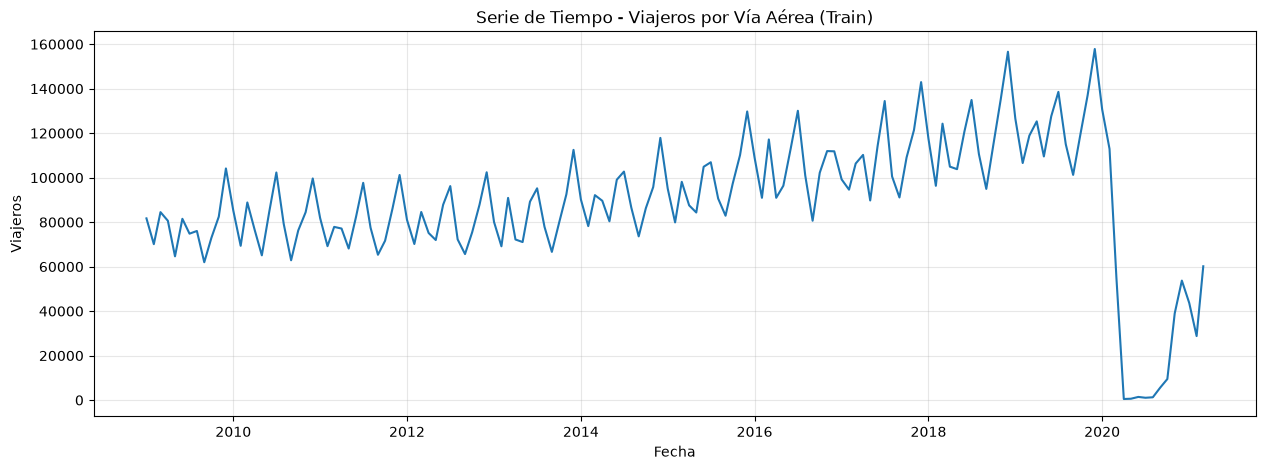

In [6]:
ts_aérea = train_series['Aérea']['Aérea']
print(f"Inicio: {ts_aérea.index.min().strftime('%Y-%m')}  |  Fin: {ts_aérea.index.max().strftime('%Y-%m')}  |  "
      f"Frecuencia: mensual  |  N observaciones (train): {len(ts_aérea)}")

plt.figure(figsize=(15, 5))
plt.plot(ts_aérea)
plt.title('Serie de Tiempo - Viajeros por Vía Aérea (Train)')
plt.xlabel('Fecha')
plt.ylabel('Viajeros')
plt.grid(True, alpha=0.3)
plt.show()


### b) Descomposición — Aérea: ¿estacionaria en media y en varianza?

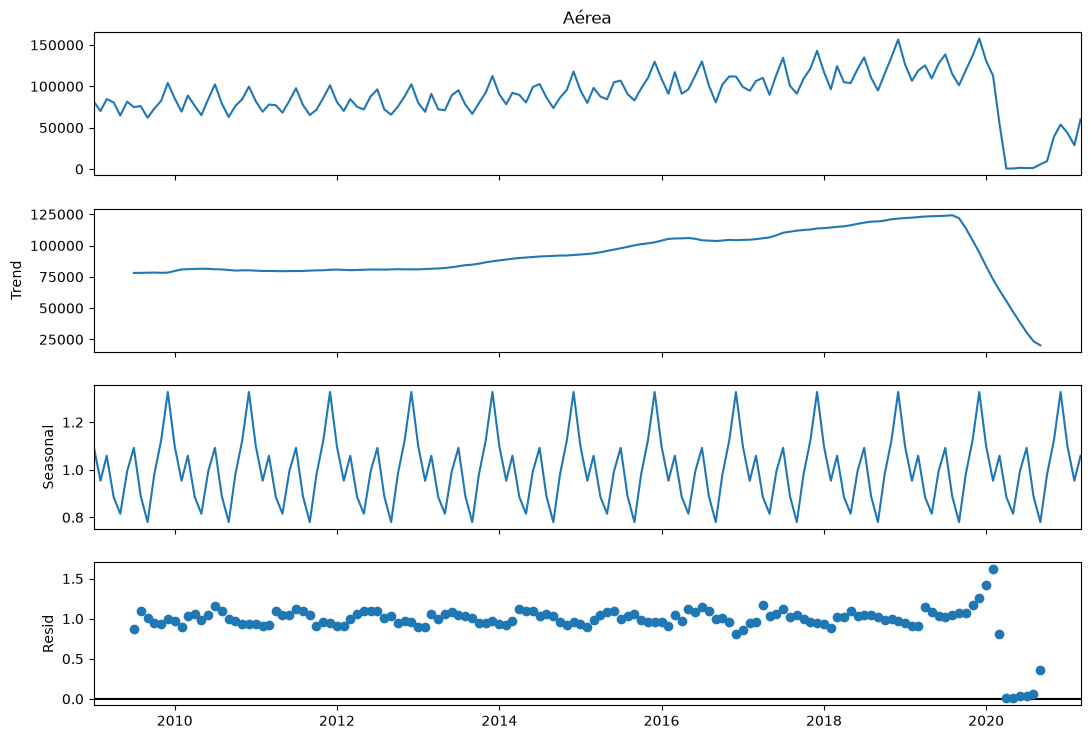

In [7]:
decomp_aérea = seasonal_decompose(ts_aérea, model='multiplicative', period=12)
decomp_aérea.plot()
plt.gcf().set_size_inches(12, 8)
plt.show()


### c) / d) ¿Es necesario transformar la serie? — Aérea


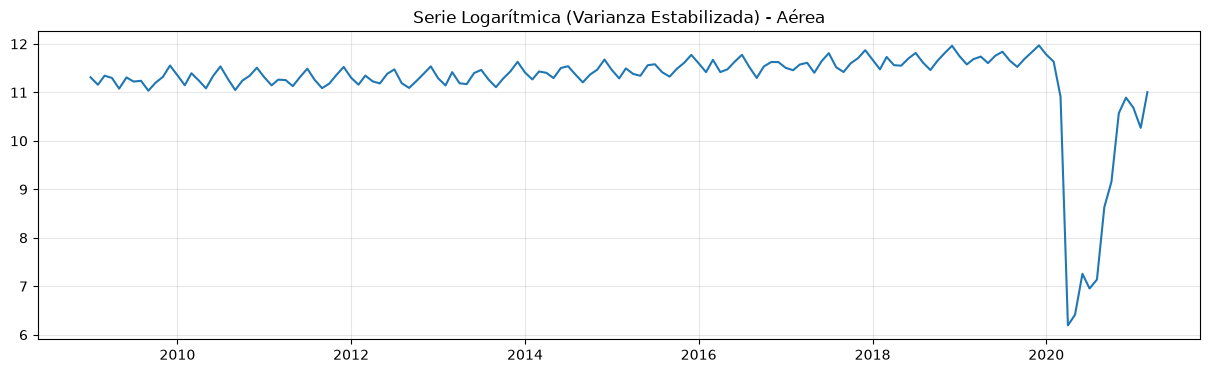

In [8]:
# Previniendo log(0) sumando una constante pequeña si hay ceros
ts_log_aérea = np.log(ts_aérea.replace(0, 1))

plt.figure(figsize=(15, 4))
plt.plot(ts_log_aérea)
plt.title('Serie Logarítmica (Varianza Estabilizada) - ' + 'Aérea')
plt.grid(True, alpha=0.3)
plt.show()


### e.i) Gráfico de autocorrelación de la serie **sin diferenciar** — Aérea


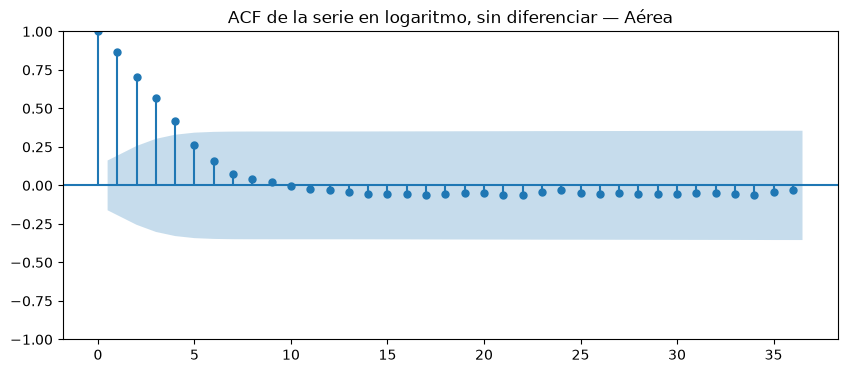

In [9]:
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(ts_log_aérea, lags=36, ax=ax)
ax.set_title('ACF de la serie en logaritmo, sin diferenciar — Aérea')
plt.show()


### e.ii) Corroboración con la prueba de Dickey-Fuller Aumentada (ADF) — Aérea


In [10]:
# Test ADF en d=0 (sin diferenciar) — se revisa PRIMERO antes de decidir si hace falta diferenciar
dftest0 = adfuller(ts_log_aérea.dropna())
print('P-value ADF (d=0, sin diferenciar):', dftest0[1])

if dftest0[1] <= 0.05:
    d_adf_aérea = 0
    print(">> p-value <= 0.05: el ADF puro sugiere que la serie YA sería estacionaria en media sin diferenciar.")
else:
    dftest1 = adfuller(ts_log_aérea.diff().dropna())
    print('P-value ADF (d=1):', dftest1[1])
    if dftest1[1] <= 0.05:
        d_adf_aérea = 1
    else:
        dftest2 = adfuller(ts_log_aérea.diff().diff().dropna())
        print('P-value ADF (d=2):', dftest2[1])
        d_adf_aérea = 2
    print(f">> Según el ADF, la serie alcanza estacionariedad en media con d={d_adf_aérea}.")


P-value ADF (d=0, sin diferenciar): 0.00131887064484284
>> p-value <= 0.05: el ADF puro sugiere que la serie YA sería estacionaria en media sin diferenciar.


In [11]:
d_opt_aérea = 1 if d_adf_aérea == 0 else d_adf_aérea
print(f"d_opt final usado para Aérea: {d_opt_aérea}  (ADF puro sugería d={d_adf_aérea})")


d_opt final usado para Aérea: 1  (ADF puro sugería d=0)


### f) Selección de p, d, q con base en ACF/PACF, y validación con `auto_arima` — Aérea


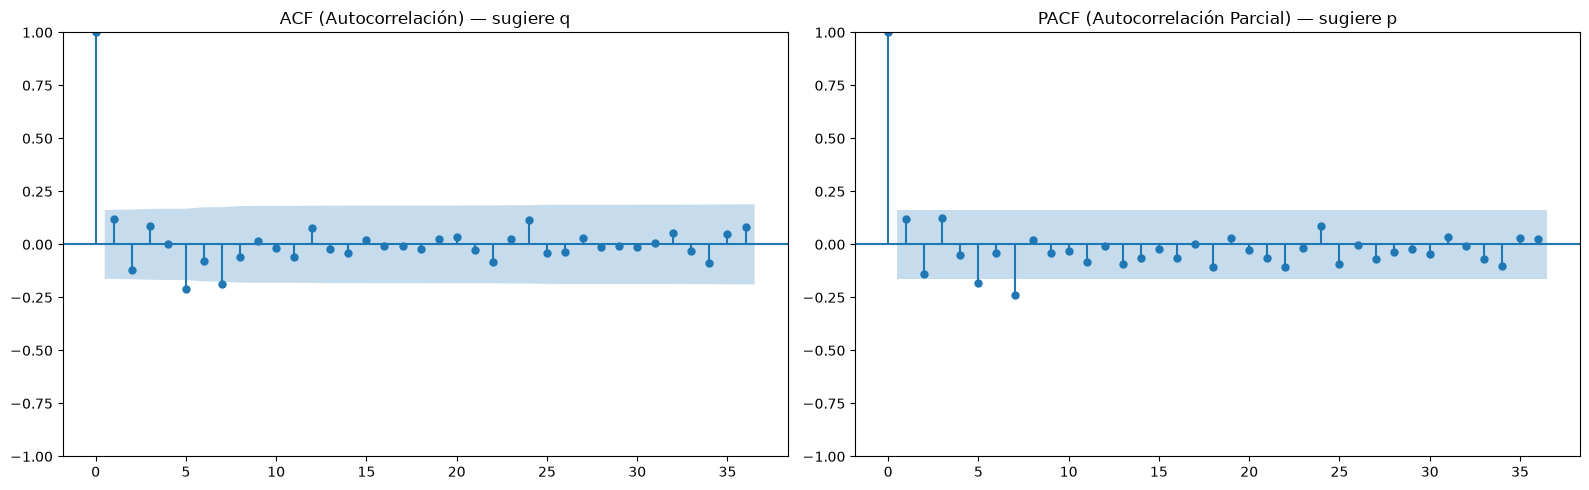

In [12]:
ts_estacionaria_aérea = ts_log_aérea.diff(d_opt_aérea).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(ts_estacionaria_aérea, lags=36, ax=axes[0])
axes[0].set_title('ACF (Autocorrelación) — sugiere q')
plot_pacf(ts_estacionaria_aérea, lags=36, ax=axes[1], method='ywm')
axes[1].set_title('PACF (Autocorrelación Parcial) — sugiere p')
plt.tight_layout()
plt.show()


In [13]:
print('Buscando el mejor modelo SARIMA para Aérea...')
auto_model_aérea = pm.auto_arima(ts_log_aérea,
                              seasonal=True, m=12,
                              d=d_opt_aérea, D=1,
                              max_p=3, max_q=3, max_P=2, max_Q=2,
                              trace=True,
                              error_action='ignore',
                              suppress_warnings=True,
                              stepwise=True)

print('\nResumen del mejor modelo encontrado por auto_arima:')
print(auto_model_aérea.summary())


Buscando el mejor modelo SARIMA para Aérea...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=182.514, Time=0.44 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=190.332, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=185.495, Time=0.03 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=185.829, Time=0.07 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=180.665, Time=0.43 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=185.422, Time=0.16 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=182.144, Time=0.50 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=184.888, Time=0.29 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=188.658, Time=0.55 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=188.813, Time=0.15 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=188.676, Time=0.12 sec
 ARIMA(3,1,2)(0,1,1)[12]             : AIC=186.954, Time=0.36 sec
 ARIMA(2,1,3)(0,1,1)[12]             : AIC=183.525, Time=0.24 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=190.096, T

### g) Varios modelos ARIMA/SARIMA — comparación de residuos, AIC y BIC — Aérea


In [14]:
p_a, d_a, q_a = auto_model_aérea.order
P_a, D_a, Q_a, s_a = auto_model_aérea.seasonal_order

candidatos_aérea = [
    {'nombre': 'Candidato 1 (auto_arima)', 'order': (p_a, d_a, q_a), 'seasonal_order': (P_a, D_a, Q_a, s_a)},
    {'nombre': 'Candidato 2 (AR adicional)', 'order': (min(p_a + 1, 3), d_a, q_a), 'seasonal_order': (P_a, D_a, Q_a, s_a)},
    {'nombre': 'Candidato 3 (parsimonioso)', 'order': (1, d_a, 1), 'seasonal_order': (0, D_a, 1, s_a)},
]

resultados_aérea = []
for cand in candidatos_aérea:
    try:
        modelo_fit = SARIMAX(ts_log_aérea, order=cand['order'], seasonal_order=cand['seasonal_order'],
                              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=100)
        resultados_aérea.append({**cand, 'aic': modelo_fit.aic, 'bic': modelo_fit.bic, 'modelo': modelo_fit})
    except Exception as e:
        print(f"No se pudo ajustar {cand['nombre']}: {e}")

tabla_candidatos_aérea = pd.DataFrame([
    {'Modelo': r['nombre'], 'Orden': f"{r['order']}x{r['seasonal_order']}",
      'AIC': round(r['aic'], 2), 'BIC': round(r['bic'], 2)}
    for r in resultados_aérea
])
display(Markdown(tabla_candidatos_aérea.to_markdown(index=False)))

mejor_arima_aérea = min(resultados_aérea, key=lambda r: r['aic'])
print(f"\n=> Mejor modelo ARIMA/SARIMA por AIC para Aérea: {mejor_arima_aérea['nombre']} "
      f"{mejor_arima_aérea['order']}x{mejor_arima_aérea['seasonal_order']} "
      f"(AIC={mejor_arima_aérea['aic']:.2f}, BIC={mejor_arima_aérea['bic']:.2f})")


| Modelo                     | Orden                   |    AIC |    BIC |
|:---------------------------|:------------------------|-------:|-------:|
| Candidato 1 (auto_arima)   | (2, 1, 2)x(0, 1, 1, 12) | 169.82 | 186.49 |
| Candidato 2 (AR adicional) | (3, 1, 2)x(0, 1, 1, 12) | 178.37 | 197.82 |
| Candidato 3 (parsimonioso) | (1, 1, 1)x(0, 1, 1, 12) | 177.61 | 188.76 |


=> Mejor modelo ARIMA/SARIMA por AIC para Aérea: Candidato 1 (auto_arima) (2, 1, 2)x(0, 1, 1, 12) (AIC=169.82, BIC=186.49)


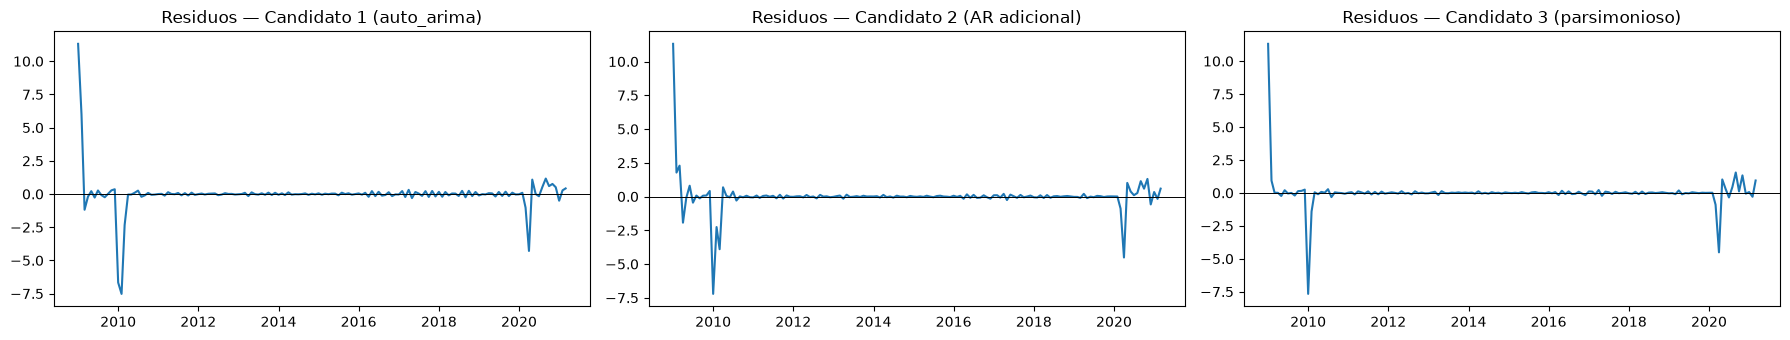

In [15]:
fig, axes = plt.subplots(1, len(resultados_aérea), figsize=(6*len(resultados_aérea), 3.5))
for ax, r in zip(axes, resultados_aérea):
    ax.plot(r['modelo'].resid)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(f"Residuos — {r['nombre']}")
plt.tight_layout()
plt.show()


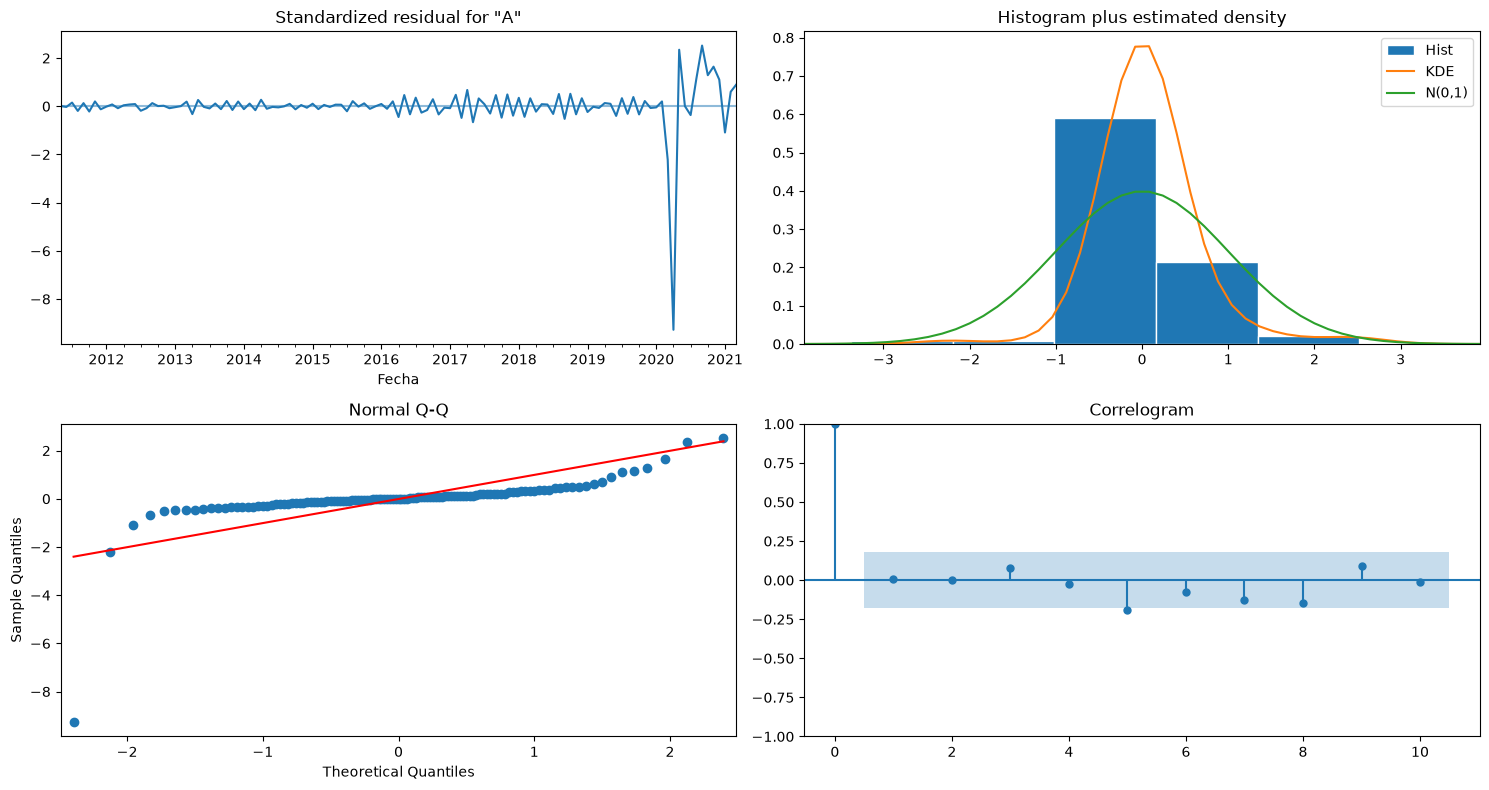

In [16]:
mejor_arima_aérea['modelo'].plot_diagnostics(figsize=(15, 8))
plt.tight_layout()
plt.show()


### h) Modelos alternativos — Prophet, Holt-Winters y Seasonal Naive — Aérea


In [17]:
test_ts_aérea = test_series['Aérea']['Aérea']
n_test_aérea = len(test_ts_aérea)

# 1. Predicción ARIMA/SARIMA (mejor modelo del inciso g, convertido de logaritmo a escala original)
pred_log_arima = mejor_arima_aérea['modelo'].get_forecast(steps=n_test_aérea).predicted_mean
pred_arima_aérea = np.exp(pred_log_arima)
pred_arima_aérea.index = test_ts_aérea.index

# 2. Holt-Winters
hw_model = ExponentialSmoothing(ts_aérea, trend='mul', seasonal='mul', seasonal_periods=12).fit(optimized=True)
pred_hw_aérea = hw_model.forecast(n_test_aérea)

# 3. Seasonal Naive
# El pronóstico es repetir el último año de entrenamiento (últimos 12 meses)
last_year = ts_aérea.iloc[-12:].values
pred_snaive_vals = np.tile(last_year, int(np.ceil(n_test_aérea / 12.0)))[:n_test_aérea]
pred_snaive_aérea = pd.Series(pred_snaive_vals, index=test_ts_aérea.index)

# 4. Prophet
prophet_df = pd.DataFrame({'ds': ts_aérea.index, 'y': ts_aérea.values})
m_prophet = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m_prophet.fit(prophet_df)
future = m_prophet.make_future_dataframe(periods=n_test_aérea, freq='MS')
forecast = m_prophet.predict(future)
pred_prophet_aérea = forecast.set_index('ds')['yhat'].iloc[-n_test_aérea:]

print('Modelos alternativos ajustados y predicciones generadas.')


22:07:26 - cmdstanpy - INFO - Chain [1] start processing
22:07:26 - cmdstanpy - INFO - Chain [1] done processing


Modelos alternativos ajustados y predicciones generadas.


### i) Predicción de los valores de la serie en el conjunto de prueba — Aérea

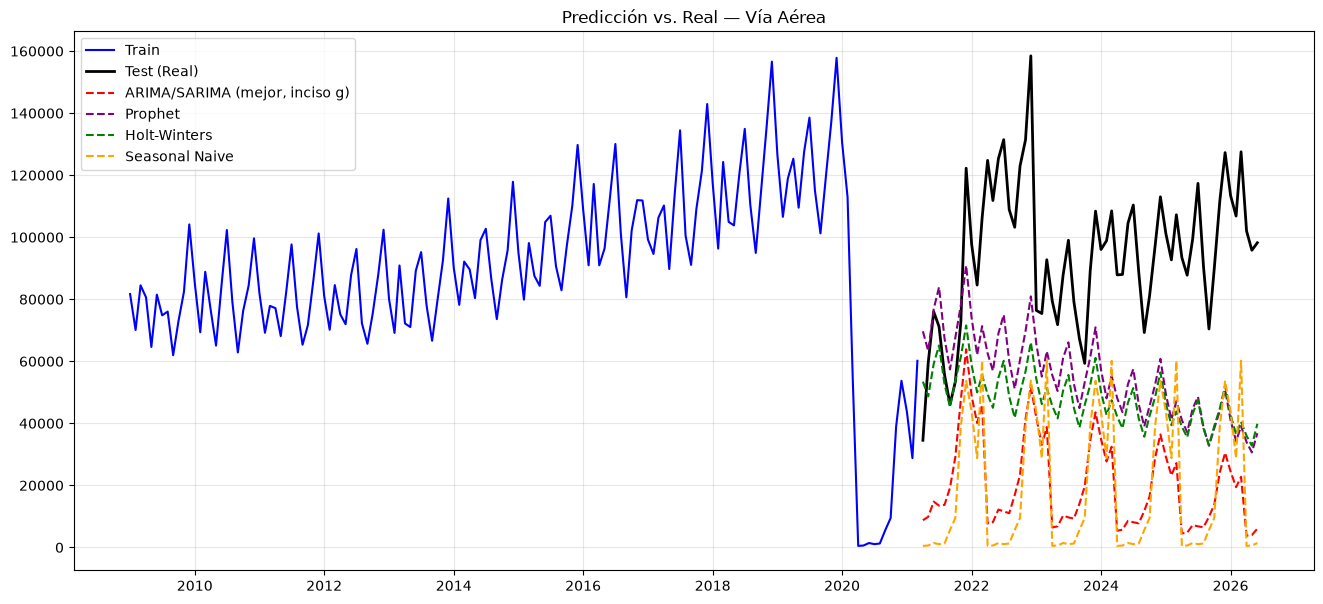

In [18]:
plt.figure(figsize=(16, 7))
plt.plot(ts_aérea.index, ts_aérea, label='Train', color='blue')
plt.plot(test_ts_aérea.index, test_ts_aérea, label='Test (Real)', color='black', linewidth=2)

plt.plot(pred_arima_aérea.index, pred_arima_aérea, label='ARIMA/SARIMA (mejor, inciso g)', color='red', linestyle='--')
plt.plot(pred_prophet_aérea.index, pred_prophet_aérea, label='Prophet', color='purple', linestyle='--')
plt.plot(pred_hw_aérea.index, pred_hw_aérea, label='Holt-Winters', color='green', linestyle='--')
plt.plot(pred_snaive_aérea.index, pred_snaive_aérea, label='Seasonal Naive', color='orange', linestyle='--')

plt.title('Predicción vs. Real — Vía Aérea')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### j) Comparación de modelos mediante MAE, RMSE, AIC y BIC — Aérea

In [19]:
metricas_aérea = []

m_arima = calcular_metricas(test_ts_aérea, pred_arima_aérea)
m_prophet_m = calcular_metricas(test_ts_aérea, pred_prophet_aérea)
m_hw = calcular_metricas(test_ts_aérea, pred_hw_aérea)
m_snaive = calcular_metricas(test_ts_aérea, pred_snaive_aérea)

# AIC y BIC del mejor modelo ARIMA/SARIMA (inciso g)
aic_arima = mejor_arima_aérea['aic']
bic_arima = mejor_arima_aérea['bic']

metricas_aérea.append(['ARIMA/SARIMA', round(m_arima[0], 2), round(m_arima[1], 2), round(aic_arima, 2), round(bic_arima, 2)])
metricas_aérea.append(['Prophet', round(m_prophet_m[0], 2), round(m_prophet_m[1], 2), '—', '—'])
metricas_aérea.append(['Holt-Winters', round(m_hw[0], 2), round(m_hw[1], 2), '—', '—'])
metricas_aérea.append(['Seasonal Naive', round(m_snaive[0], 2), round(m_snaive[1], 2), '—', '—'])

df_res_aérea = pd.DataFrame(metricas_aérea, columns=['Modelo', 'MAE', 'RMSE', 'AIC', 'BIC'])
display(Markdown(df_res_aérea.to_markdown(index=False)))


| Modelo         |     MAE |    RMSE | AIC    | BIC    |
|:---------------|--------:|--------:|:-------|:-------|
| ARIMA/SARIMA   | 73980.4 | 77694   | 169.82 | 186.49 |
| Prophet        | 42320.6 | 47090.8 | —      | —      |
| Holt-Winters   | 47451.9 | 52027.6 | —      | —      |
| Seasonal Naive | 75103.7 | 79077.3 | —      | —      |

### k) Selección del mejor modelo — Aérea

In [20]:
mejor_modelo_idx_aérea = df_res_aérea['RMSE'].astype(float).idxmin()
mejor_modelo_nombre_aérea = df_res_aérea.iloc[mejor_modelo_idx_aérea]['Modelo']

# Verificación cruzada: ¿MAE y RMSE coinciden en el mismo ganador?
mejor_por_mae_aérea = df_res_aérea.iloc[df_res_aérea['MAE'].astype(float).idxmin()]['Modelo']
coincide = "sí" if mejor_por_mae_aérea == mejor_modelo_nombre_aérea else "no"

print(f"=> Modelo seleccionado para la vía Aérea (menor RMSE): {mejor_modelo_nombre_aérea}")
print(f"   (Por MAE el ganador sería: {mejor_por_mae_aérea} — ¿coincide con RMSE? {coincide})")


=> Modelo seleccionado para la vía Aérea (menor RMSE): Prophet
   (Por MAE el ganador sería: Prophet — ¿coincide con RMSE? sí)


---
---
# SERIE: VÍA TERRESTRE

### a) Inicio, fin, frecuencia, gráfico e interpretación — Terrestre

Inicio: 2009-01  |  Fin: 2021-03  |  Frecuencia: mensual  |  N observaciones (train): 147


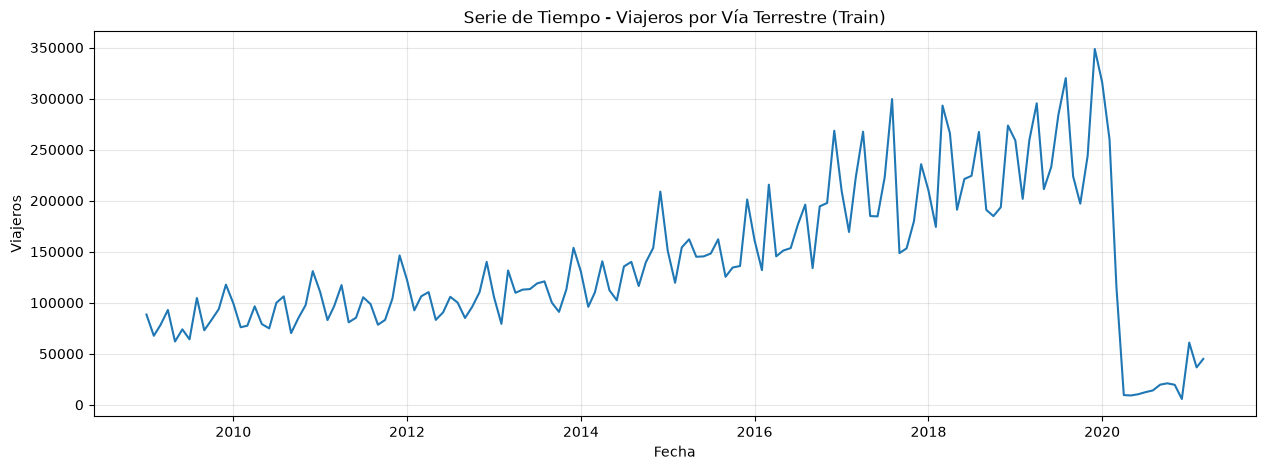

In [21]:
ts_terrestre = train_series['Terrestre']['Terrestre']
print(f"Inicio: {ts_terrestre.index.min().strftime('%Y-%m')}  |  Fin: {ts_terrestre.index.max().strftime('%Y-%m')}  |  "
      f"Frecuencia: mensual  |  N observaciones (train): {len(ts_terrestre)}")

plt.figure(figsize=(15, 5))
plt.plot(ts_terrestre)
plt.title('Serie de Tiempo - Viajeros por Vía Terrestre (Train)')
plt.xlabel('Fecha')
plt.ylabel('Viajeros')
plt.grid(True, alpha=0.3)
plt.show()


### b) Descomposición — Terrestre: ¿estacionaria en media y en varianza?

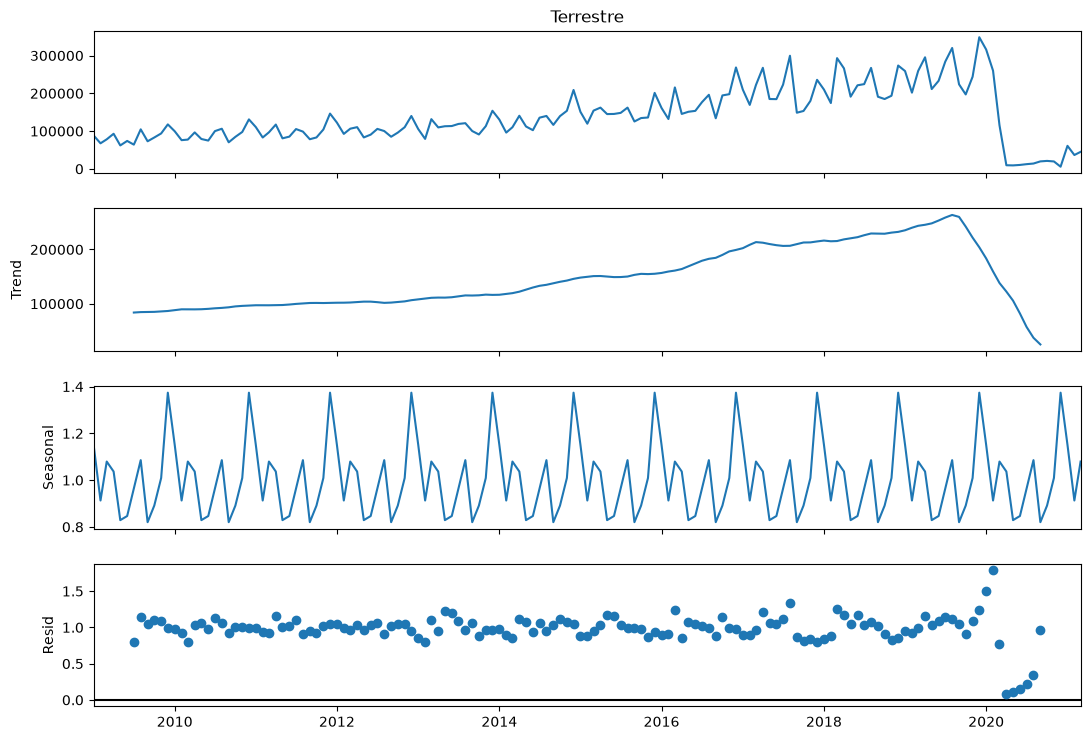

In [22]:
decomp_terrestre = seasonal_decompose(ts_terrestre, model='multiplicative', period=12)
decomp_terrestre.plot()
plt.gcf().set_size_inches(12, 8)
plt.show()


### c) / d) ¿Es necesario transformar la serie? — Terrestre


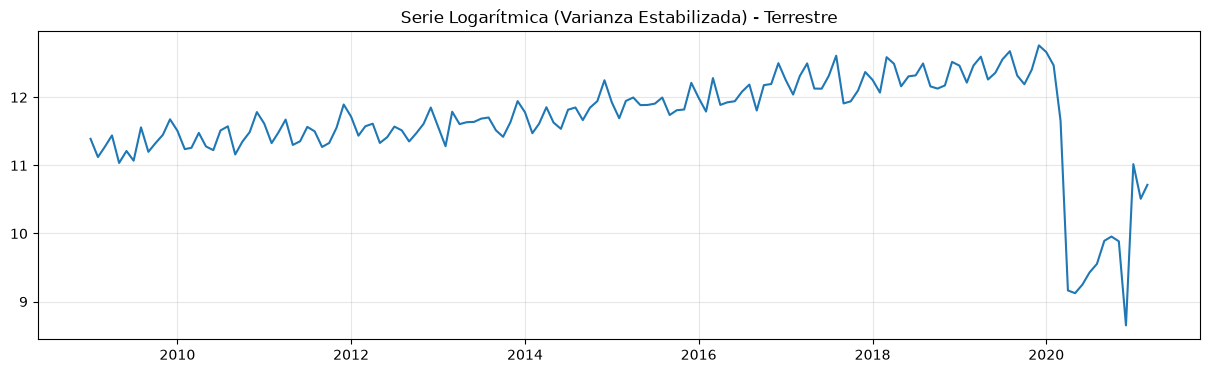

In [23]:
# Previniendo log(0) sumando una constante pequeña si hay ceros
ts_log_terrestre = np.log(ts_terrestre.replace(0, 1))

plt.figure(figsize=(15, 4))
plt.plot(ts_log_terrestre)
plt.title('Serie Logarítmica (Varianza Estabilizada) - ' + 'Terrestre')
plt.grid(True, alpha=0.3)
plt.show()


### e.i) Gráfico de autocorrelación de la serie **sin diferenciar** — Terrestre


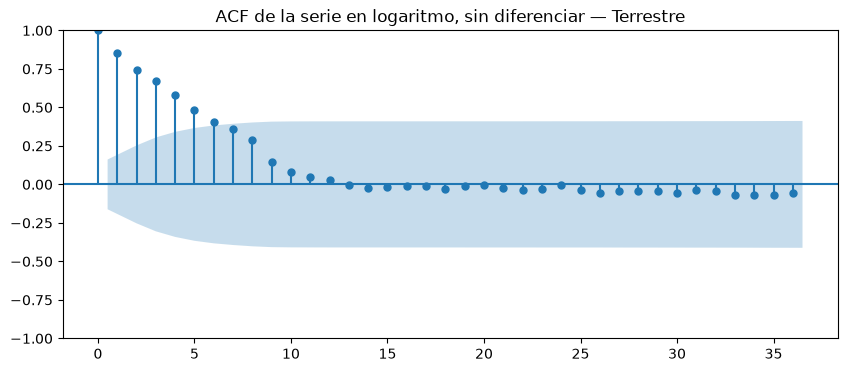

In [24]:
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(ts_log_terrestre, lags=36, ax=ax)
ax.set_title('ACF de la serie en logaritmo, sin diferenciar — Terrestre')
plt.show()


### e.ii) Corroboración con la prueba de Dickey-Fuller Aumentada (ADF) — Terrestre


In [25]:
# Test ADF en d=0 (sin diferenciar) — se revisa PRIMERO antes de decidir si hace falta diferenciar
dftest0 = adfuller(ts_log_terrestre.dropna())
print('P-value ADF (d=0, sin diferenciar):', dftest0[1])

if dftest0[1] <= 0.05:
    d_adf_terrestre = 0
    print(">> p-value <= 0.05: el ADF puro sugiere que la serie YA sería estacionaria en media sin diferenciar.")
else:
    dftest1 = adfuller(ts_log_terrestre.diff().dropna())
    print('P-value ADF (d=1):', dftest1[1])
    if dftest1[1] <= 0.05:
        d_adf_terrestre = 1
    else:
        dftest2 = adfuller(ts_log_terrestre.diff().diff().dropna())
        print('P-value ADF (d=2):', dftest2[1])
        d_adf_terrestre = 2
    print(f">> Según el ADF, la serie alcanza estacionariedad en media con d={d_adf_terrestre}.")


P-value ADF (d=0, sin diferenciar): 0.5619084066790495
P-value ADF (d=1): 0.00907018615087996
>> Según el ADF, la serie alcanza estacionariedad en media con d=1.


In [26]:
d_opt_terrestre = 1 if d_adf_terrestre == 0 else d_adf_terrestre
print(f"d_opt final usado para Terrestre: {d_opt_terrestre}  (ADF puro sugería d={d_adf_terrestre})")


d_opt final usado para Terrestre: 1  (ADF puro sugería d=1)


### f) Selección de p, d, q con base en ACF/PACF, y validación con `auto_arima` — Terrestre


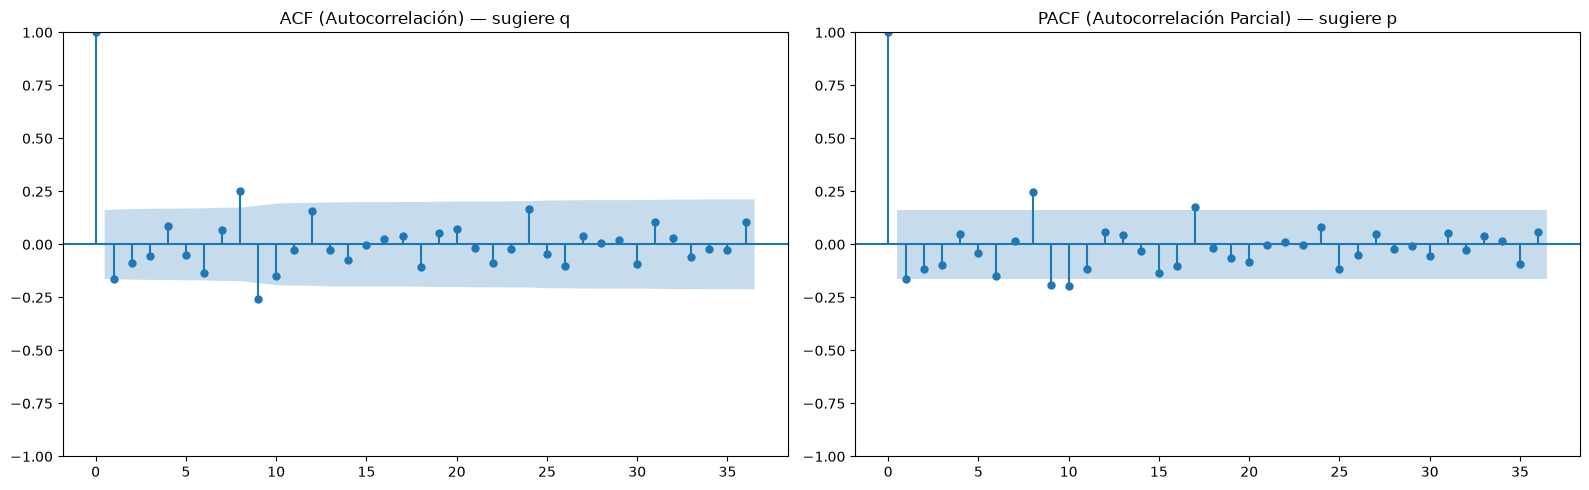

In [27]:
ts_estacionaria_terrestre = ts_log_terrestre.diff(d_opt_terrestre).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(ts_estacionaria_terrestre, lags=36, ax=axes[0])
axes[0].set_title('ACF (Autocorrelación) — sugiere q')
plot_pacf(ts_estacionaria_terrestre, lags=36, ax=axes[1], method='ywm')
axes[1].set_title('PACF (Autocorrelación Parcial) — sugiere p')
plt.tight_layout()
plt.show()


In [28]:
print('Buscando el mejor modelo SARIMA para Terrestre...')
auto_model_terrestre = pm.auto_arima(ts_log_terrestre,
                              seasonal=True, m=12,
                              d=d_opt_terrestre, D=1,
                              max_p=3, max_q=3, max_P=2, max_Q=2,
                              trace=True,
                              error_action='ignore',
                              suppress_warnings=True,
                              stepwise=True)

print('\nResumen del mejor modelo encontrado por auto_arima:')
print(auto_model_terrestre.summary())


Buscando el mejor modelo SARIMA para Terrestre...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=130.148, Time=0.40 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=140.850, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=130.062, Time=0.04 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=130.079, Time=0.07 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=137.799, Time=0.01 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=131.864, Time=0.08 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=131.627, Time=0.09 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=130.211, Time=0.07 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=133.481, Time=0.36 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=132.239, Time=0.03 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=132.057, Time=0.05 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=132.029, Time=0.11 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=130.029, Time=0.04 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=137.98

### g) Varios modelos ARIMA/SARIMA — comparación de residuos, AIC y BIC — Terrestre


In [29]:
p_a, d_a, q_a = auto_model_terrestre.order
P_a, D_a, Q_a, s_a = auto_model_terrestre.seasonal_order

candidatos_terrestre = [
    {'nombre': 'Candidato 1 (auto_arima)', 'order': (p_a, d_a, q_a), 'seasonal_order': (P_a, D_a, Q_a, s_a)},
    {'nombre': 'Candidato 2 (AR adicional)', 'order': (min(p_a + 1, 3), d_a, q_a), 'seasonal_order': (P_a, D_a, Q_a, s_a)},
    {'nombre': 'Candidato 3 (parsimonioso)', 'order': (1, d_a, 1), 'seasonal_order': (0, D_a, 1, s_a)},
]

resultados_terrestre = []
for cand in candidatos_terrestre:
    try:
        modelo_fit = SARIMAX(ts_log_terrestre, order=cand['order'], seasonal_order=cand['seasonal_order'],
                              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=100)
        resultados_terrestre.append({**cand, 'aic': modelo_fit.aic, 'bic': modelo_fit.bic, 'modelo': modelo_fit})
    except Exception as e:
        print(f"No se pudo ajustar {cand['nombre']}: {e}")

tabla_candidatos_terrestre = pd.DataFrame([
    {'Modelo': r['nombre'], 'Orden': f"{r['order']}x{r['seasonal_order']}",
      'AIC': round(r['aic'], 2), 'BIC': round(r['bic'], 2)}
    for r in resultados_terrestre
])
display(Markdown(tabla_candidatos_terrestre.to_markdown(index=False)))

mejor_arima_terrestre = min(resultados_terrestre, key=lambda r: r['aic'])
print(f"\n=> Mejor modelo ARIMA/SARIMA por AIC para Terrestre: {mejor_arima_terrestre['nombre']} "
      f"{mejor_arima_terrestre['order']}x{mejor_arima_terrestre['seasonal_order']} "
      f"(AIC={mejor_arima_terrestre['aic']:.2f}, BIC={mejor_arima_terrestre['bic']:.2f})")


| Modelo                     | Orden                   |    AIC |    BIC |
|:---------------------------|:------------------------|-------:|-------:|
| Candidato 1 (auto_arima)   | (1, 1, 3)x(0, 1, 1, 12) | 118.04 | 134.66 |
| Candidato 2 (AR adicional) | (2, 1, 3)x(0, 1, 1, 12) | 115.9  | 135.3  |
| Candidato 3 (parsimonioso) | (1, 1, 1)x(0, 1, 1, 12) | 127.09 | 138.24 |


=> Mejor modelo ARIMA/SARIMA por AIC para Terrestre: Candidato 2 (AR adicional) (2, 1, 3)x(0, 1, 1, 12) (AIC=115.90, BIC=135.30)


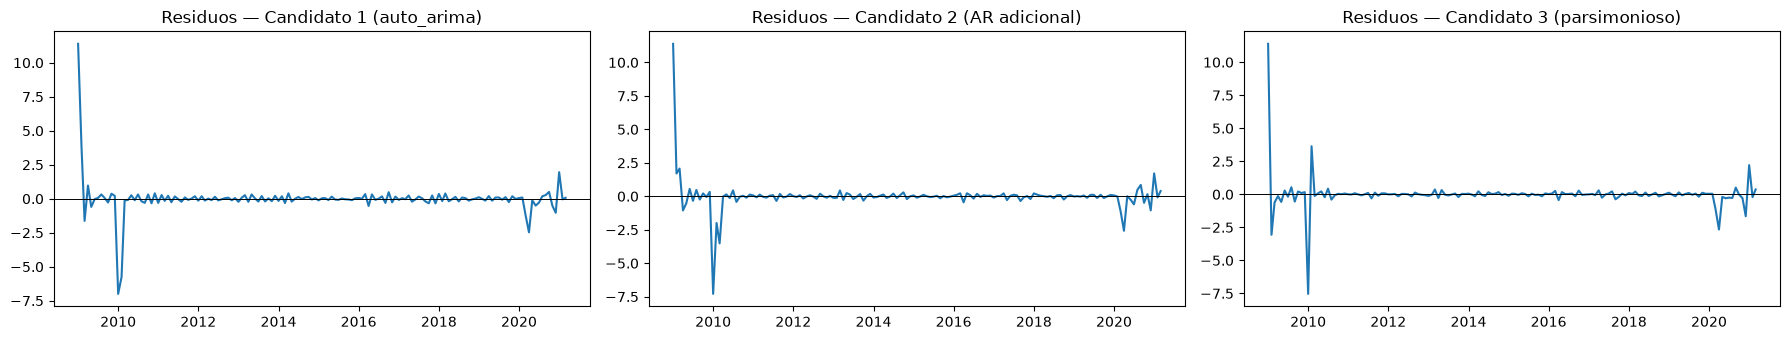

In [30]:
fig, axes = plt.subplots(1, len(resultados_terrestre), figsize=(6*len(resultados_terrestre), 3.5))
for ax, r in zip(axes, resultados_terrestre):
    ax.plot(r['modelo'].resid)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(f"Residuos — {r['nombre']}")
plt.tight_layout()
plt.show()


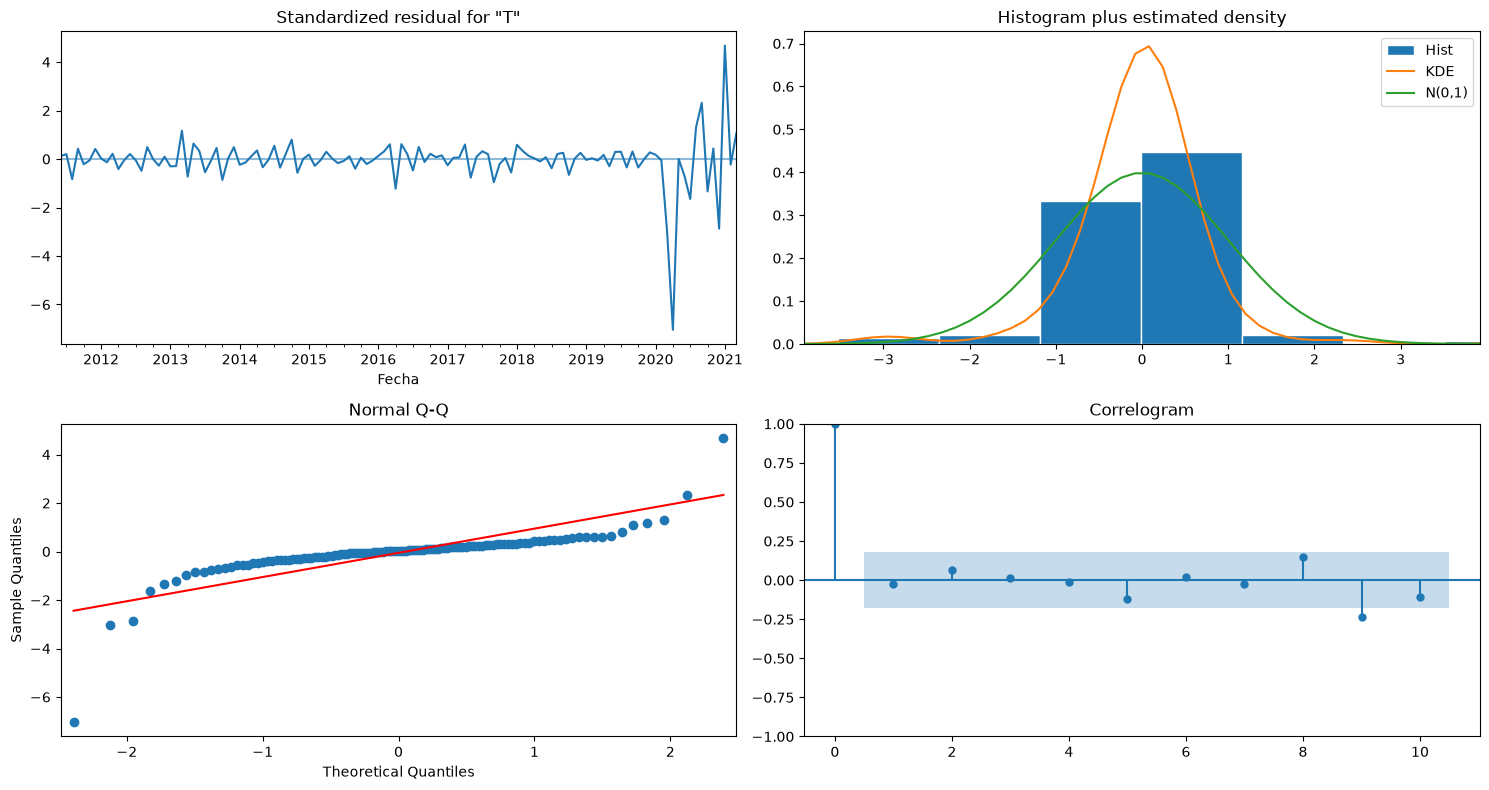

In [31]:
mejor_arima_terrestre['modelo'].plot_diagnostics(figsize=(15, 8))
plt.tight_layout()
plt.show()


### h) Modelos alternativos — Prophet, Holt-Winters y Seasonal Naive — Terrestre


In [32]:
test_ts_terrestre = test_series['Terrestre']['Terrestre']
n_test_terrestre = len(test_ts_terrestre)

# 1. Predicción ARIMA/SARIMA (mejor modelo del inciso g, convertido de logaritmo a escala original)
pred_log_arima = mejor_arima_terrestre['modelo'].get_forecast(steps=n_test_terrestre).predicted_mean
pred_arima_terrestre = np.exp(pred_log_arima)
pred_arima_terrestre.index = test_ts_terrestre.index

# 2. Holt-Winters
hw_model = ExponentialSmoothing(ts_terrestre, trend='mul', seasonal='mul', seasonal_periods=12).fit(optimized=True)
pred_hw_terrestre = hw_model.forecast(n_test_terrestre)

# 3. Seasonal Naive
# El pronóstico es repetir el último año de entrenamiento (últimos 12 meses)
last_year = ts_terrestre.iloc[-12:].values
pred_snaive_vals = np.tile(last_year, int(np.ceil(n_test_terrestre / 12.0)))[:n_test_terrestre]
pred_snaive_terrestre = pd.Series(pred_snaive_vals, index=test_ts_terrestre.index)

# 4. Prophet
prophet_df = pd.DataFrame({'ds': ts_terrestre.index, 'y': ts_terrestre.values})
m_prophet = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m_prophet.fit(prophet_df)
future = m_prophet.make_future_dataframe(periods=n_test_terrestre, freq='MS')
forecast = m_prophet.predict(future)
pred_prophet_terrestre = forecast.set_index('ds')['yhat'].iloc[-n_test_terrestre:]

print('Modelos alternativos ajustados y predicciones generadas.')


22:07:38 - cmdstanpy - INFO - Chain [1] start processing
22:07:38 - cmdstanpy - INFO - Chain [1] done processing


Modelos alternativos ajustados y predicciones generadas.


### i) Predicción de los valores de la serie en el conjunto de prueba — Terrestre

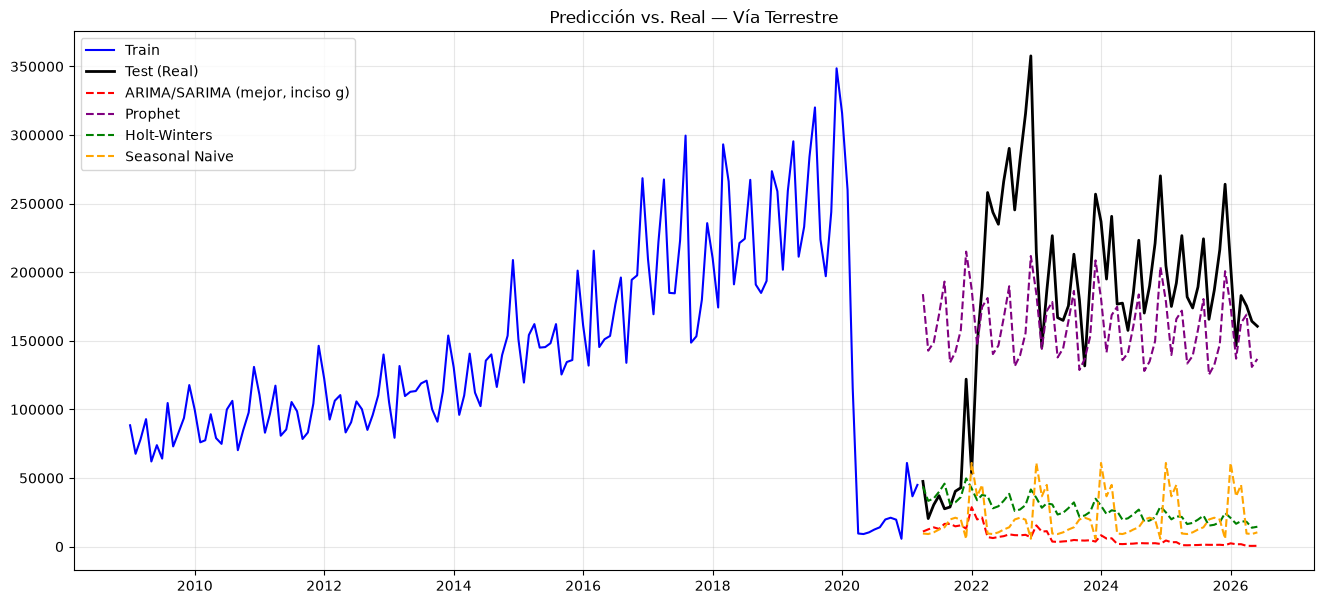

In [33]:
plt.figure(figsize=(16, 7))
plt.plot(ts_terrestre.index, ts_terrestre, label='Train', color='blue')
plt.plot(test_ts_terrestre.index, test_ts_terrestre, label='Test (Real)', color='black', linewidth=2)

plt.plot(pred_arima_terrestre.index, pred_arima_terrestre, label='ARIMA/SARIMA (mejor, inciso g)', color='red', linestyle='--')
plt.plot(pred_prophet_terrestre.index, pred_prophet_terrestre, label='Prophet', color='purple', linestyle='--')
plt.plot(pred_hw_terrestre.index, pred_hw_terrestre, label='Holt-Winters', color='green', linestyle='--')
plt.plot(pred_snaive_terrestre.index, pred_snaive_terrestre, label='Seasonal Naive', color='orange', linestyle='--')

plt.title('Predicción vs. Real — Vía Terrestre')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### j) Comparación de modelos mediante MAE, RMSE, AIC y BIC — Terrestre

In [34]:
metricas_terrestre = []

m_arima = calcular_metricas(test_ts_terrestre, pred_arima_terrestre)
m_prophet_m = calcular_metricas(test_ts_terrestre, pred_prophet_terrestre)
m_hw = calcular_metricas(test_ts_terrestre, pred_hw_terrestre)
m_snaive = calcular_metricas(test_ts_terrestre, pred_snaive_terrestre)

# AIC y BIC del mejor modelo ARIMA/SARIMA (inciso g)
aic_arima = mejor_arima_terrestre['aic']
bic_arima = mejor_arima_terrestre['bic']

metricas_terrestre.append(['ARIMA/SARIMA', round(m_arima[0], 2), round(m_arima[1], 2), round(aic_arima, 2), round(bic_arima, 2)])
metricas_terrestre.append(['Prophet', round(m_prophet_m[0], 2), round(m_prophet_m[1], 2), '—', '—'])
metricas_terrestre.append(['Holt-Winters', round(m_hw[0], 2), round(m_hw[1], 2), '—', '—'])
metricas_terrestre.append(['Seasonal Naive', round(m_snaive[0], 2), round(m_snaive[1], 2), '—', '—'])

df_res_terrestre = pd.DataFrame(metricas_terrestre, columns=['Modelo', 'MAE', 'RMSE', 'AIC', 'BIC'])
display(Markdown(df_res_terrestre.to_markdown(index=False)))


| Modelo         |      MAE |     RMSE | AIC   | BIC   |
|:---------------|---------:|---------:|:------|:------|
| ARIMA/SARIMA   | 174721   | 190648   | 115.9 | 135.3 |
| Prophet        |  60128.4 |  74425.9 | —     | —     |
| Holt-Winters   | 155275   | 171480   | —     | —     |
| Seasonal Naive | 160013   | 176653   | —     | —     |

### k) Selección del mejor modelo — Terrestre

In [35]:
mejor_modelo_idx_terrestre = df_res_terrestre['RMSE'].astype(float).idxmin()
mejor_modelo_nombre_terrestre = df_res_terrestre.iloc[mejor_modelo_idx_terrestre]['Modelo']

# Verificación cruzada: ¿MAE y RMSE coinciden en el mismo ganador?
mejor_por_mae_terrestre = df_res_terrestre.iloc[df_res_terrestre['MAE'].astype(float).idxmin()]['Modelo']
coincide = "sí" if mejor_por_mae_terrestre == mejor_modelo_nombre_terrestre else "no"

print(f"=> Modelo seleccionado para la vía Terrestre (menor RMSE): {mejor_modelo_nombre_terrestre}")
print(f"   (Por MAE el ganador sería: {mejor_por_mae_terrestre} — ¿coincide con RMSE? {coincide})")


=> Modelo seleccionado para la vía Terrestre (menor RMSE): Prophet
   (Por MAE el ganador sería: Prophet — ¿coincide con RMSE? sí)


---
---
# SERIE: VÍA MARÍTIMA

### a) Inicio, fin, frecuencia, gráfico e interpretación — Marítima

Inicio: 2009-01  |  Fin: 2021-03  |  Frecuencia: mensual  |  N observaciones (train): 147


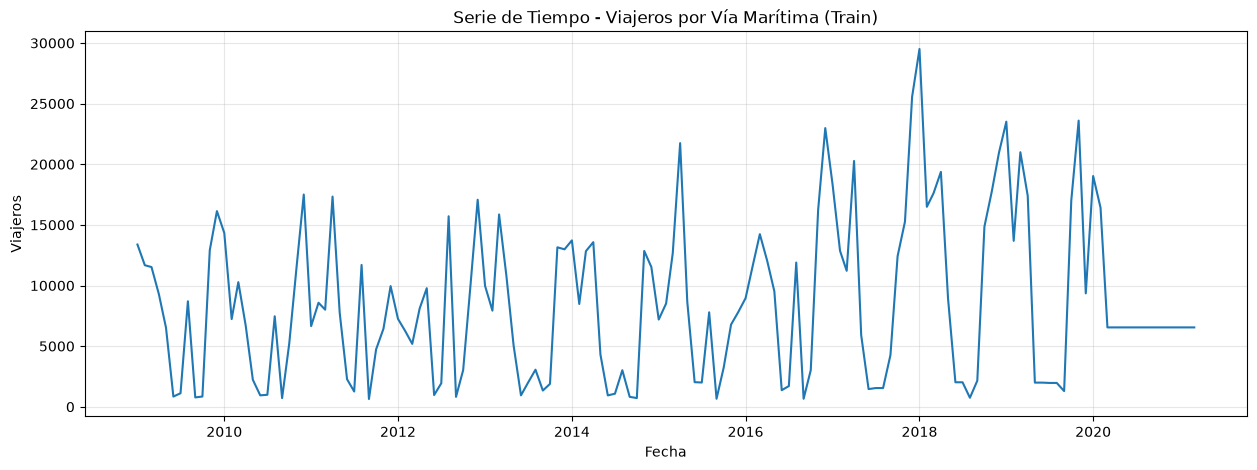

In [36]:
ts_marítima = train_series['Marítima']['Marítima']
print(f"Inicio: {ts_marítima.index.min().strftime('%Y-%m')}  |  Fin: {ts_marítima.index.max().strftime('%Y-%m')}  |  "
      f"Frecuencia: mensual  |  N observaciones (train): {len(ts_marítima)}")

plt.figure(figsize=(15, 5))
plt.plot(ts_marítima)
plt.title('Serie de Tiempo - Viajeros por Vía Marítima (Train)')
plt.xlabel('Fecha')
plt.ylabel('Viajeros')
plt.grid(True, alpha=0.3)
plt.show()


### b) Descomposición — Marítima: ¿estacionaria en media y en varianza?

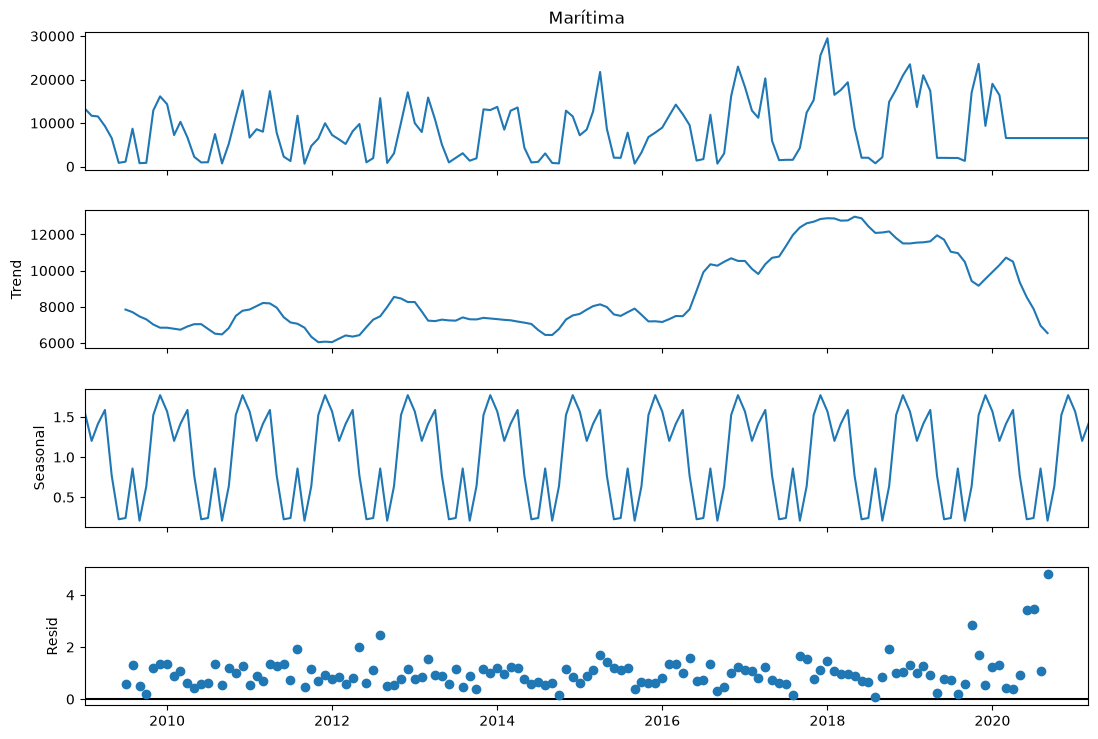

In [37]:
decomp_marítima = seasonal_decompose(ts_marítima, model='multiplicative', period=12)
decomp_marítima.plot()
plt.gcf().set_size_inches(12, 8)
plt.show()


### c) / d) ¿Es necesario transformar la serie? — Marítima


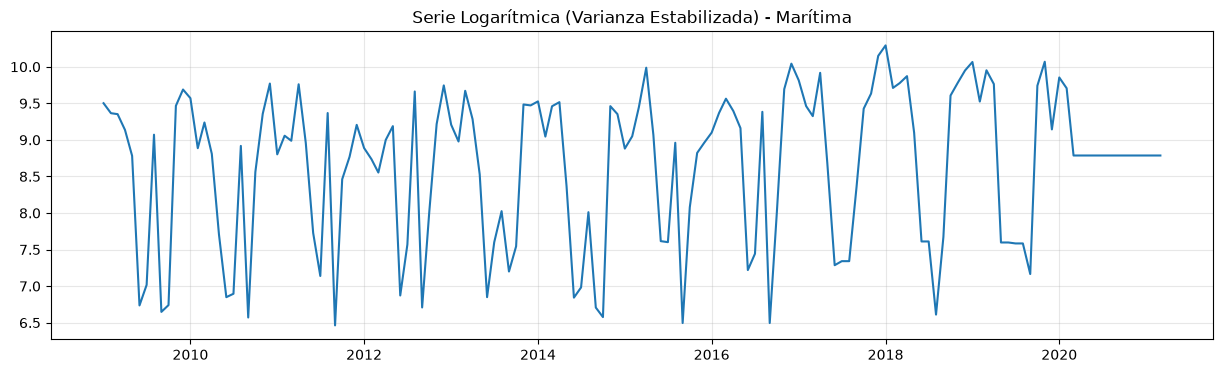

In [38]:
# Previniendo log(0) sumando una constante pequeña si hay ceros
ts_log_marítima = np.log(ts_marítima.replace(0, 1))

plt.figure(figsize=(15, 4))
plt.plot(ts_log_marítima)
plt.title('Serie Logarítmica (Varianza Estabilizada) - ' + 'Marítima')
plt.grid(True, alpha=0.3)
plt.show()


### e.i) Gráfico de autocorrelación de la serie **sin diferenciar** — Marítima


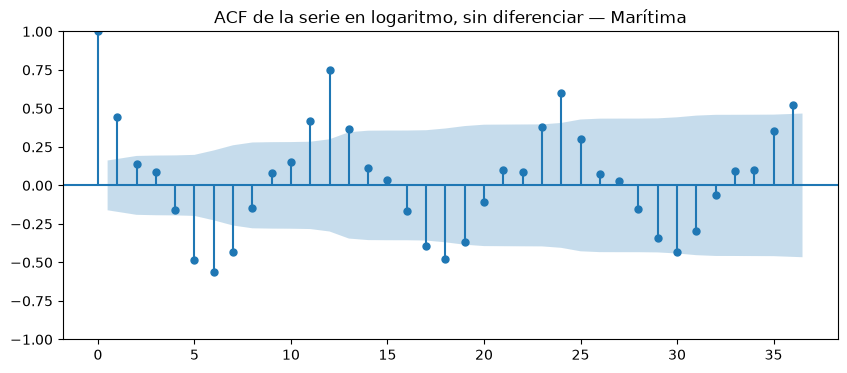

In [39]:
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(ts_log_marítima, lags=36, ax=ax)
ax.set_title('ACF de la serie en logaritmo, sin diferenciar — Marítima')
plt.show()


### e.ii) Corroboración con la prueba de Dickey-Fuller Aumentada (ADF) — Marítima


In [40]:
# Test ADF en d=0 (sin diferenciar) — se revisa PRIMERO antes de decidir si hace falta diferenciar
dftest0 = adfuller(ts_log_marítima.dropna())
print('P-value ADF (d=0, sin diferenciar):', dftest0[1])

if dftest0[1] <= 0.05:
    d_adf_marítima = 0
    print(">> p-value <= 0.05: el ADF puro sugiere que la serie YA sería estacionaria en media sin diferenciar.")
else:
    dftest1 = adfuller(ts_log_marítima.diff().dropna())
    print('P-value ADF (d=1):', dftest1[1])
    if dftest1[1] <= 0.05:
        d_adf_marítima = 1
    else:
        dftest2 = adfuller(ts_log_marítima.diff().diff().dropna())
        print('P-value ADF (d=2):', dftest2[1])
        d_adf_marítima = 2
    print(f">> Según el ADF, la serie alcanza estacionariedad en media con d={d_adf_marítima}.")


P-value ADF (d=0, sin diferenciar): 0.4471668951349478
P-value ADF (d=1): 6.370699321150615e-26
>> Según el ADF, la serie alcanza estacionariedad en media con d=1.


In [41]:
d_opt_marítima = 1 if d_adf_marítima == 0 else d_adf_marítima
print(f"d_opt final usado para Marítima: {d_opt_marítima}  (ADF puro sugería d={d_adf_marítima})")


d_opt final usado para Marítima: 1  (ADF puro sugería d=1)


### f) Selección de p, d, q con base en ACF/PACF, y validación con `auto_arima` — Marítima


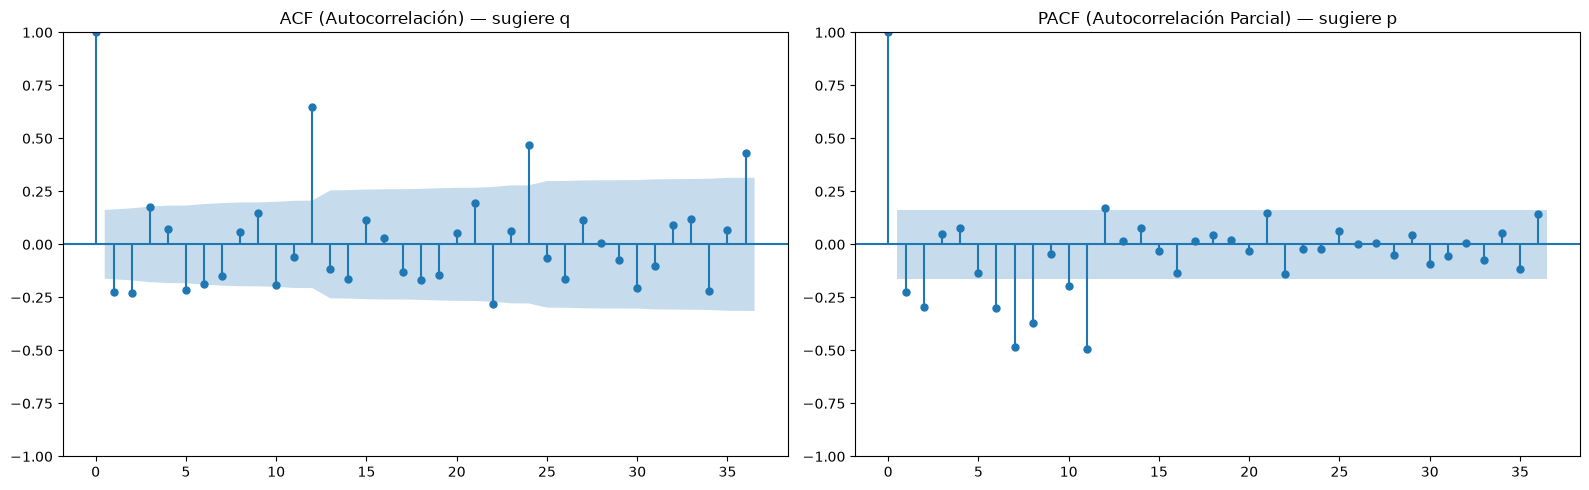

In [42]:
ts_estacionaria_marítima = ts_log_marítima.diff(d_opt_marítima).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(ts_estacionaria_marítima, lags=36, ax=axes[0])
axes[0].set_title('ACF (Autocorrelación) — sugiere q')
plot_pacf(ts_estacionaria_marítima, lags=36, ax=axes[1], method='ywm')
axes[1].set_title('PACF (Autocorrelación Parcial) — sugiere p')
plt.tight_layout()
plt.show()


In [43]:
print('Buscando el mejor modelo SARIMA para Marítima...')
auto_model_marítima = pm.auto_arima(ts_log_marítima,
                              seasonal=True, m=12,
                              d=d_opt_marítima, D=1,
                              max_p=3, max_q=3, max_P=2, max_Q=2,
                              trace=True,
                              error_action='ignore',
                              suppress_warnings=True,
                              stepwise=True)

print('\nResumen del mejor modelo encontrado por auto_arima:')
print(auto_model_marítima.summary())


Buscando el mejor modelo SARIMA para Marítima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=inf, Time=0.44 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=343.193, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=308.039, Time=0.03 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.19 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=316.957, Time=0.01 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=299.725, Time=0.05 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=296.124, Time=0.09 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=296.856, Time=0.08 sec
 ARIMA(1,1,0)(2,1,2)[12]             : AIC=296.252, Time=0.20 sec
 ARIMA(1,1,0)(1,1,2)[12]             : AIC=297.957, Time=0.13 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=315.149, Time=0.08 sec
 ARIMA(2,1,0)(2,1,1)[12]             : AIC=280.552, Time=0.13 sec
 ARIMA(2,1,0)(1,1,1)[12]             : AIC=284.453, Time=0.10 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=287.858, Time=0

### g) Varios modelos ARIMA/SARIMA — comparación de residuos, AIC y BIC — Marítima


In [44]:
p_a, d_a, q_a = auto_model_marítima.order
P_a, D_a, Q_a, s_a = auto_model_marítima.seasonal_order

candidatos_marítima = [
    {'nombre': 'Candidato 1 (auto_arima)', 'order': (p_a, d_a, q_a), 'seasonal_order': (P_a, D_a, Q_a, s_a)},
    {'nombre': 'Candidato 2 (AR adicional)', 'order': (min(p_a + 1, 3), d_a, q_a), 'seasonal_order': (P_a, D_a, Q_a, s_a)},
    {'nombre': 'Candidato 3 (parsimonioso)', 'order': (1, d_a, 1), 'seasonal_order': (0, D_a, 1, s_a)},
]

resultados_marítima = []
for cand in candidatos_marítima:
    try:
        modelo_fit = SARIMAX(ts_log_marítima, order=cand['order'], seasonal_order=cand['seasonal_order'],
                              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=100)
        resultados_marítima.append({**cand, 'aic': modelo_fit.aic, 'bic': modelo_fit.bic, 'modelo': modelo_fit})
    except Exception as e:
        print(f"No se pudo ajustar {cand['nombre']}: {e}")

tabla_candidatos_marítima = pd.DataFrame([
    {'Modelo': r['nombre'], 'Orden': f"{r['order']}x{r['seasonal_order']}",
      'AIC': round(r['aic'], 2), 'BIC': round(r['bic'], 2)}
    for r in resultados_marítima
])
display(Markdown(tabla_candidatos_marítima.to_markdown(index=False)))

mejor_arima_marítima = min(resultados_marítima, key=lambda r: r['aic'])
print(f"\n=> Mejor modelo ARIMA/SARIMA por AIC para Marítima: {mejor_arima_marítima['nombre']} "
      f"{mejor_arima_marítima['order']}x{mejor_arima_marítima['seasonal_order']} "
      f"(AIC={mejor_arima_marítima['aic']:.2f}, BIC={mejor_arima_marítima['bic']:.2f})")


| Modelo                     | Orden                   |    AIC |    BIC |
|:---------------------------|:------------------------|-------:|-------:|
| Candidato 1 (auto_arima)   | (3, 1, 0)x(2, 1, 1, 12) | 228.23 | 246.94 |
| Candidato 2 (AR adicional) | (3, 1, 0)x(2, 1, 1, 12) | 228.23 | 246.94 |
| Candidato 3 (parsimonioso) | (1, 1, 1)x(0, 1, 1, 12) | 235.27 | 246.42 |


=> Mejor modelo ARIMA/SARIMA por AIC para Marítima: Candidato 1 (auto_arima) (3, 1, 0)x(2, 1, 1, 12) (AIC=228.23, BIC=246.94)


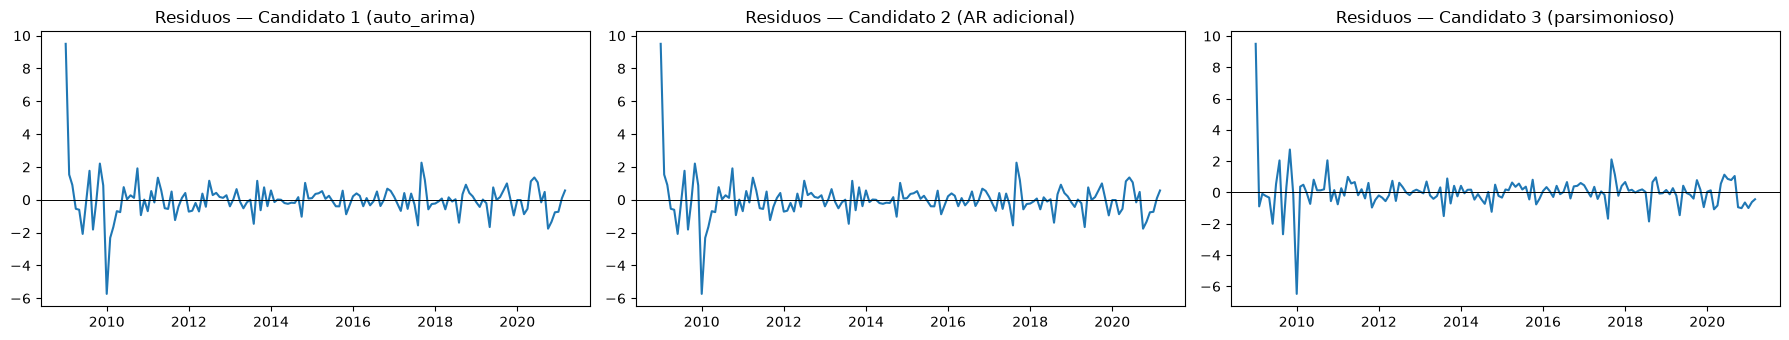

In [45]:
fig, axes = plt.subplots(1, len(resultados_marítima), figsize=(6*len(resultados_marítima), 3.5))
for ax, r in zip(axes, resultados_marítima):
    ax.plot(r['modelo'].resid)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(f"Residuos — {r['nombre']}")
plt.tight_layout()
plt.show()


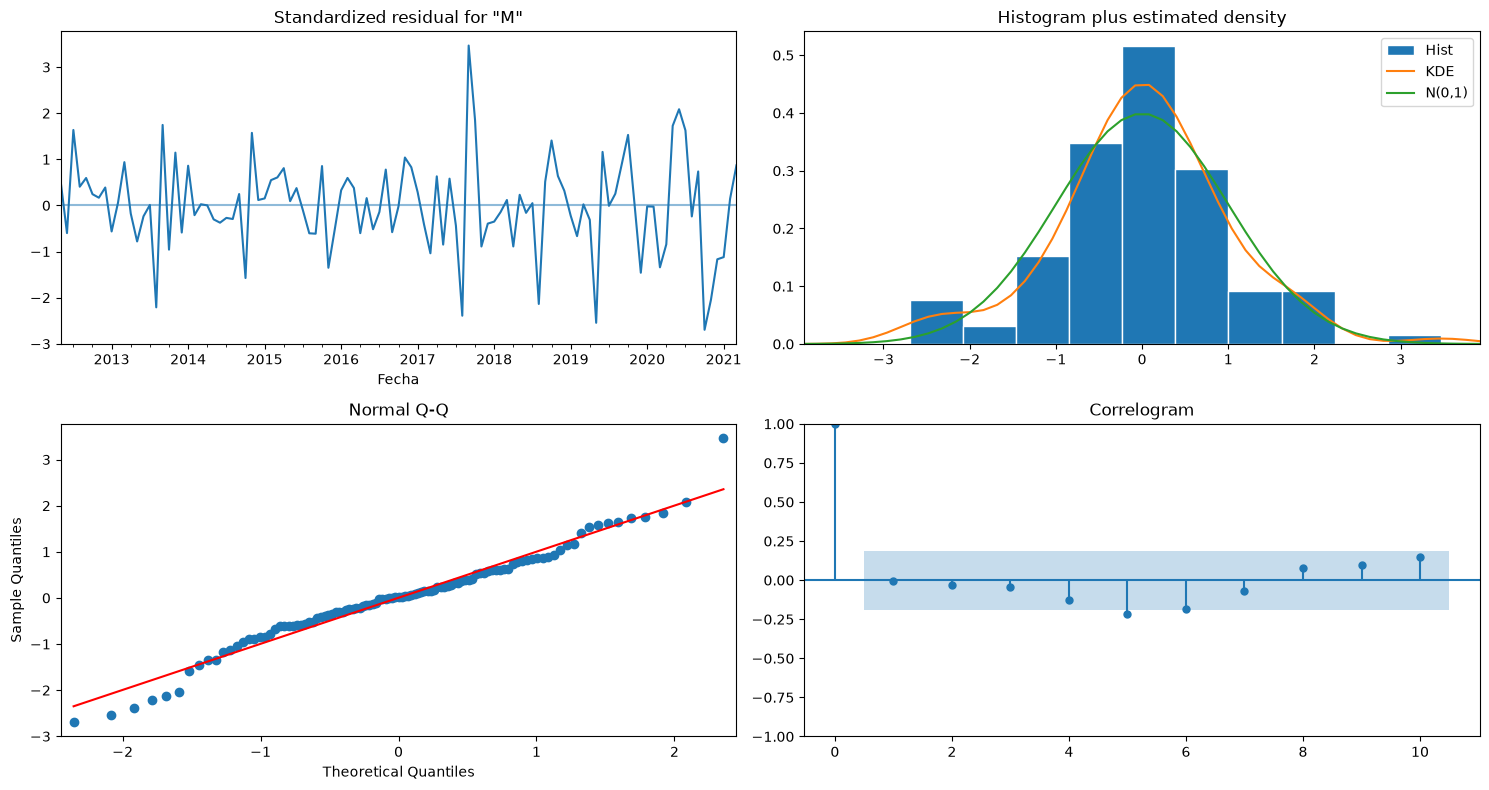

In [46]:
mejor_arima_marítima['modelo'].plot_diagnostics(figsize=(15, 8))
plt.tight_layout()
plt.show()


### h) Modelos alternativos — Prophet, Holt-Winters y Seasonal Naive — Marítima


In [47]:
test_ts_marítima = test_series['Marítima']['Marítima']
n_test_marítima = len(test_ts_marítima)

# 1. Predicción ARIMA/SARIMA (mejor modelo del inciso g, convertido de logaritmo a escala original)
pred_log_arima = mejor_arima_marítima['modelo'].get_forecast(steps=n_test_marítima).predicted_mean
pred_arima_marítima = np.exp(pred_log_arima)
pred_arima_marítima.index = test_ts_marítima.index

# 2. Holt-Winters
hw_model = ExponentialSmoothing(ts_marítima, trend='mul', seasonal='mul', seasonal_periods=12).fit(optimized=True)
pred_hw_marítima = hw_model.forecast(n_test_marítima)

# 3. Seasonal Naive
# El pronóstico es repetir el último año de entrenamiento (últimos 12 meses)
last_year = ts_marítima.iloc[-12:].values
pred_snaive_vals = np.tile(last_year, int(np.ceil(n_test_marítima / 12.0)))[:n_test_marítima]
pred_snaive_marítima = pd.Series(pred_snaive_vals, index=test_ts_marítima.index)

# 4. Prophet
prophet_df = pd.DataFrame({'ds': ts_marítima.index, 'y': ts_marítima.values})
m_prophet = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m_prophet.fit(prophet_df)
future = m_prophet.make_future_dataframe(periods=n_test_marítima, freq='MS')
forecast = m_prophet.predict(future)
pred_prophet_marítima = forecast.set_index('ds')['yhat'].iloc[-n_test_marítima:]

print('Modelos alternativos ajustados y predicciones generadas.')


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
22:07:43 - cmdstanpy - INFO - Chain [1] start processing
22:07:43 - cmdstanpy - INFO - Chain [1] done processing


Modelos alternativos ajustados y predicciones generadas.


### i) Predicción de los valores de la serie en el conjunto de prueba — Marítima

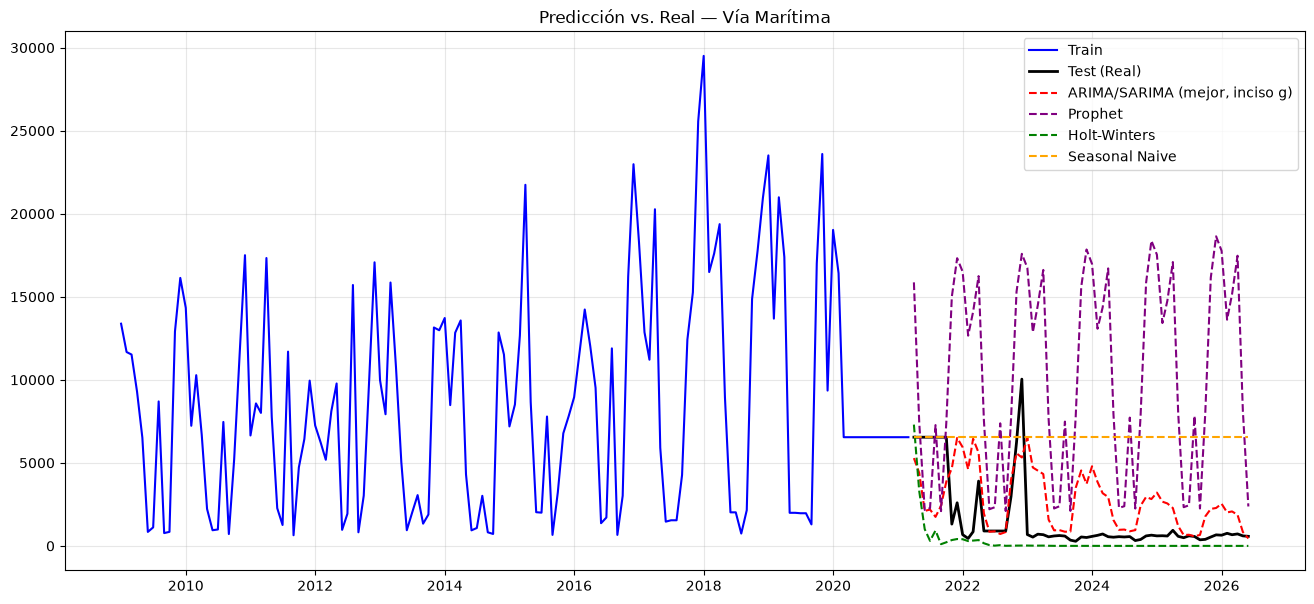

In [48]:
plt.figure(figsize=(16, 7))
plt.plot(ts_marítima.index, ts_marítima, label='Train', color='blue')
plt.plot(test_ts_marítima.index, test_ts_marítima, label='Test (Real)', color='black', linewidth=2)

plt.plot(pred_arima_marítima.index, pred_arima_marítima, label='ARIMA/SARIMA (mejor, inciso g)', color='red', linestyle='--')
plt.plot(pred_prophet_marítima.index, pred_prophet_marítima, label='Prophet', color='purple', linestyle='--')
plt.plot(pred_hw_marítima.index, pred_hw_marítima, label='Holt-Winters', color='green', linestyle='--')
plt.plot(pred_snaive_marítima.index, pred_snaive_marítima, label='Seasonal Naive', color='orange', linestyle='--')

plt.title('Predicción vs. Real — Vía Marítima')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### j) Comparación de modelos mediante MAE, RMSE, AIC y BIC — Marítima

In [49]:
metricas_marítima = []

m_arima = calcular_metricas(test_ts_marítima, pred_arima_marítima)
m_prophet_m = calcular_metricas(test_ts_marítima, pred_prophet_marítima)
m_hw = calcular_metricas(test_ts_marítima, pred_hw_marítima)
m_snaive = calcular_metricas(test_ts_marítima, pred_snaive_marítima)

# AIC y BIC del mejor modelo ARIMA/SARIMA (inciso g)
aic_arima = mejor_arima_marítima['aic']
bic_arima = mejor_arima_marítima['bic']

metricas_marítima.append(['ARIMA/SARIMA', round(m_arima[0], 2), round(m_arima[1], 2), round(aic_arima, 2), round(bic_arima, 2)])
metricas_marítima.append(['Prophet', round(m_prophet_m[0], 2), round(m_prophet_m[1], 2), '—', '—'])
metricas_marítima.append(['Holt-Winters', round(m_hw[0], 2), round(m_hw[1], 2), '—', '—'])
metricas_marítima.append(['Seasonal Naive', round(m_snaive[0], 2), round(m_snaive[1], 2), '—', '—'])

df_res_marítima = pd.DataFrame(metricas_marítima, columns=['Modelo', 'MAE', 'RMSE', 'AIC', 'BIC'])
display(Markdown(df_res_marítima.to_markdown(index=False)))


| Modelo         |     MAE |     RMSE | AIC    | BIC    |
|:---------------|--------:|---------:|:-------|:-------|
| ARIMA/SARIMA   | 2024.39 |  2613.24 | 228.23 | 246.94 |
| Prophet        | 9108.7  | 10787.3  | —      | —      |
| Holt-Winters   | 1417.43 |  2450.56 | —      | —      |
| Seasonal Naive | 5013.48 |  5398.75 | —      | —      |

### k) Selección del mejor modelo — Marítima

In [50]:
mejor_modelo_idx_marítima = df_res_marítima['RMSE'].astype(float).idxmin()
mejor_modelo_nombre_marítima = df_res_marítima.iloc[mejor_modelo_idx_marítima]['Modelo']

# Verificación cruzada: ¿MAE y RMSE coinciden en el mismo ganador?
mejor_por_mae_marítima = df_res_marítima.iloc[df_res_marítima['MAE'].astype(float).idxmin()]['Modelo']
coincide = "sí" if mejor_por_mae_marítima == mejor_modelo_nombre_marítima else "no"

print(f"=> Modelo seleccionado para la vía Marítima (menor RMSE): {mejor_modelo_nombre_marítima}")
print(f"   (Por MAE el ganador sería: {mejor_por_mae_marítima} — ¿coincide con RMSE? {coincide})")


=> Modelo seleccionado para la vía Marítima (menor RMSE): Holt-Winters
   (Por MAE el ganador sería: Holt-Winters — ¿coincide con RMSE? sí)


## Análisis Comparativo

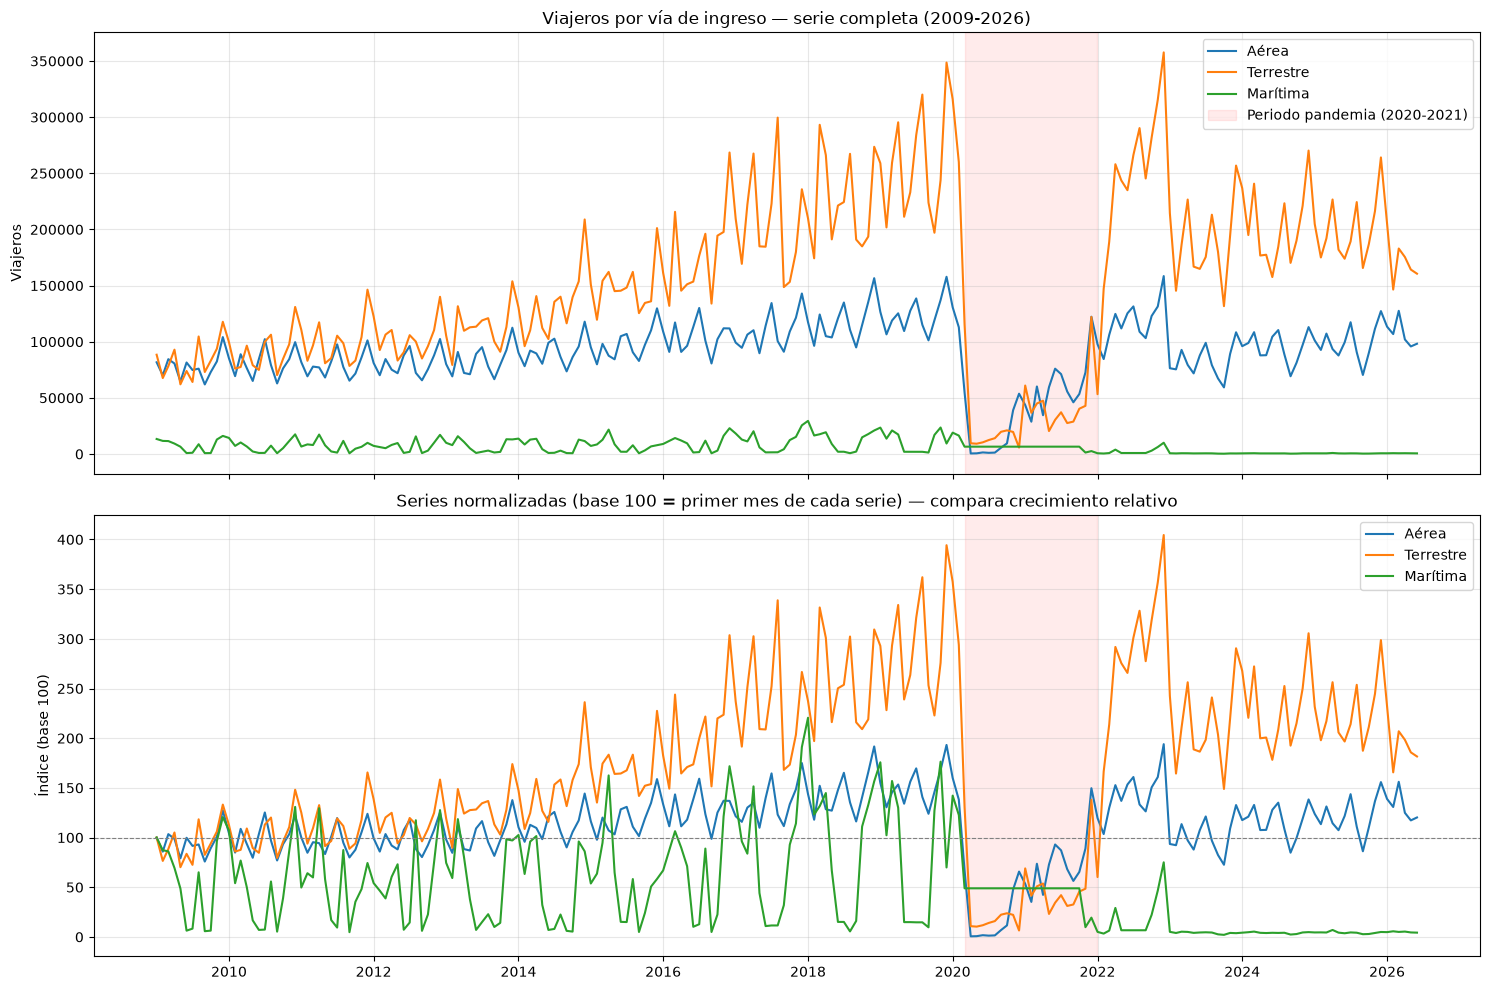

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Panel 1: series en escala original
for via in vias:
    axes[0].plot(series[via].index, series[via][via], label=via)
axes[0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'), color='red', alpha=0.08, label='Periodo pandemia (2020-2021)')
axes[0].set_title('Viajeros por vía de ingreso — serie completa (2009-2026)')
axes[0].set_ylabel('Viajeros')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: series normalizadas (índice = 100 en el primer mes de cada serie) para comparar dinámica relativa
for via in vias:
    s = series[via][via]
    s_norm = s / s.iloc[0] * 100
    axes[1].plot(s.index, s_norm, label=via)
axes[1].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'), color='red', alpha=0.08)
axes[1].axhline(100, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Series normalizadas (base 100 = primer mes de cada serie) — compara crecimiento relativo')
axes[1].set_ylabel('Índice (base 100)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [52]:
comparativo = {}

for via in vias:
    s_full = series[via][via].astype(float)
    s_log = np.log(s_full.replace(0, np.nan)).dropna()

    # Descomposición aditiva sobre el logaritmo (equivale a multiplicativa en escala original)
    decomp_full = seasonal_decompose(s_log, model='additive', period=12)
    resid = decomp_full.resid.dropna()
    seasonal_al = decomp_full.seasonal.loc[resid.index]
    trend_al = decomp_full.trend.loc[resid.index]

    var_resid = resid.var()
    F_seasonal = max(0, 1 - var_resid / (seasonal_al + resid).var())
    F_trend = max(0, 1 - var_resid / (trend_al + resid).var())

    # Crecimiento: CAGR usando solo años calendario completos (12 observaciones)
    conteo_anual = s_full.groupby(s_full.index.year).count()
    años_completos = conteo_anual[conteo_anual == 12].index
    mask_completos = s_full.index.year.isin(años_completos)
    serie_anual = s_full[mask_completos].groupby(s_full.index[mask_completos].year).mean()
    n_años = serie_anual.index.max() - serie_anual.index.min()
    cagr = (serie_anual.iloc[-1] / serie_anual.iloc[0]) ** (1 / n_años) - 1 if n_años > 0 else np.nan

    # Volatilidad
    cv_original = s_full.std() / s_full.mean()
    vol_resid = resid.std()

    # Impacto de la pandemia
    base_2019 = s_full[s_full.index.year == 2019].mean()
    min_2020 = s_full[s_full.index.year == 2020].min()
    caida_pct = (min_2020 - base_2019) / base_2019 * 100

    post_2020 = s_full[s_full.index > '2020-12-31']
    recuperados = post_2020[post_2020 >= base_2019]
    mes_recuperacion = recuperados.index.min() if len(recuperados) > 0 else None
    meses_para_recuperar = ((mes_recuperacion.year - 2020) * 12 + (mes_recuperacion.month - 1)) if mes_recuperacion is not None else np.nan

    comparativo[via] = {
        'Fuerza estacional F_S': round(F_seasonal, 3),
        'Fuerza de tendencia F_T': round(F_trend, 3),
        'CAGR anual (%)': round(cagr * 100, 2) if pd.notna(cagr) else np.nan,
        'CV serie original (%)': round(cv_original * 100, 1),
        'Volatilidad residual (log)': round(vol_resid, 3),
        'Promedio mensual 2019': round(base_2019, 0),
        'Mínimo mensual 2020': round(min_2020, 0),
        'Caída pico pandemia (%)': round(caida_pct, 1),
        'Meses hasta recuperar nivel 2019': meses_para_recuperar,
    }

df_comparativo = pd.DataFrame(comparativo).T
display(Markdown('### Tabla comparativa de estadísticos entre vías'))
display(Markdown(df_comparativo.to_markdown()))

### Tabla comparativa de estadísticos entre vías

|           |   Fuerza estacional F_S |   Fuerza de tendencia F_T |   CAGR anual (%) |   CV serie original (%) |   Volatilidad residual (log) |   Promedio mensual 2019 |   Mínimo mensual 2020 |   Caída pico pandemia (%) |   Meses hasta recuperar nivel 2019 |
|:----------|------------------------:|--------------------------:|-----------------:|------------------------:|-----------------------------:|------------------------:|----------------------:|--------------------------:|-----------------------------------:|
| Aérea     |                   0.161 |                     0.694 |             1.51 |                    30.5 |                        0.437 |                  123615 |                   489 |                     -99.6 |                                 27 |
| Terrestre |                   0.174 |                     0.827 |             5.63 |                    49.3 |                        0.298 |                  256470 |                  5715 |                     -97.8 |                                 27 |
| Marítima  |                   0.479 |                     0.663 |           -15.01 |                    98.5 |                        0.66  |                   11229 |                  6545 |                     -41.7 |                                nan |

In [53]:
total_por_via = {via: series[via][via].sum() for via in vias}
total_general = sum(total_por_via.values())
participacion = {via: round(total_por_via[via] / total_general * 100, 1) for via in vias}
via_dominante = max(participacion, key=participacion.get)

print('Participación de cada vía sobre el total histórico de viajeros (2009-2026):')
for via in vias:
    print(f'  {via}: {participacion[via]}%  (total: {int(total_por_via[via]):,} viajeros)')

Participación de cada vía sobre el total histórico de viajeros (2009-2026):
  Aérea: 36.4%  (total: 19,063,850 viajeros)
  Terrestre: 61.0%  (total: 31,995,304 viajeros)
  Marítima: 2.6%  (total: 1,364,246 viajeros)
